# SmileGuard — Dental Detection Training Pipeline

## Pipeline Overview
1. **Download** — Kaggle 6-Class Intraoral Disease Dataset
2. **Convert** — DatasetNinja annotations → YOLO format
3. **Convert** — Kaggle classification images → YOLO format (full-image bboxes)
4. **Merge** — Combine both datasets into one unified set
5. **Validate** — Verify all files are in place, check class mappings
6. **Balance Check** — Analyze class distribution & detect over/under-sampling
7. **Train** — YOLOv8 model training
8. **Evaluate** — Model performance metrics
9. **Inference** — DentalDetector class + visualization
10. **API** — Flask endpoint for integration

## Step 1 — Download Kaggle Dataset
Download the [6-Class Intraoral Disease Dataset](https://www.kaggle.com/datasets/sehrishnoords/6-class-intraoral-disease-dataset) (classification: Calculus, Caries, Gingivitis, Hypodontia, Mouth Ulcer, Tooth Discoloration).

In [24]:
# Paths to both datasets
from pathlib import Path
dental_roboflow = Path('./Dental-Dataset-roboflow')
roboflow_dataset = Path('./Roboflow-dataset')
dental_mates = Path('./Datasets/Dental_Mates')

# Read class names from both data.yaml files
import yaml
with open(dental_roboflow / 'data.yaml') as f:
    dental_classes = yaml.safe_load(f)['names']

with open(roboflow_dataset / 'data.yaml') as f:
    roboflow_classes = yaml.safe_load(f)['names']

with open(dental_mates / 'data.yaml') as f:
    mates_classes = yaml.safe_load(f)['names']

print('Dental-Dataset-roboflow classes:', dental_classes)
print('Roboflow-dataset classes:', roboflow_classes)
print('Dental_Mates classes:', mates_classes)

# Harmonize class names (example: unify capitalization, spelling, etc.)
def normalize_class(name):
    return name.strip().lower().replace(' ', '_')

dental_classes_norm = [normalize_class(c) for c in dental_classes]
roboflow_classes_norm = [normalize_class(c) for c in roboflow_classes]
mates_classes_norm = [normalize_class(c) for c in mates_classes]

print('Normalized Dental-Dataset-roboflow:', dental_classes_norm)
print('Normalized Roboflow-dataset:', roboflow_classes_norm)
print('Normalized Dental_Mates_Dataset:', mates_classes_norm)

# Check for congruence
if set(dental_classes_norm).issubset(set(roboflow_classes_norm)) or set(roboflow_classes_norm).issubset(set(dental_classes_norm)) or set(mates_classes_norm).issubset(set(dental_classes_norm)) or set(mates_classes_norm).issubset(set(mates_classes_norm)):
    print('Datasets are congruent or can be merged directly.')
else:
    print('Datasets have different classes. Manual mapping or merging required.')

Dental-Dataset-roboflow classes: ['Caries', 'Cavity', 'Crack', 'Tooth']
Roboflow-dataset classes: ['Braces', 'Caries', 'Cavity', 'Misaligned tooth', 'Plaque', 'crown']
Dental_Mates classes: ['Caries', 'Cavity', 'Crack', 'Tooth']
Normalized Dental-Dataset-roboflow: ['caries', 'cavity', 'crack', 'tooth']
Normalized Roboflow-dataset: ['braces', 'caries', 'cavity', 'misaligned_tooth', 'plaque', 'crown']
Normalized Dental_Mates_Dataset: ['caries', 'cavity', 'crack', 'tooth']
Datasets are congruent or can be merged directly.


### Remove Small Classes
Run the remove_small_classes.py script to filter out classes with too few samples from the merged dataset.

In [25]:
# Run remove_small_classes.py to filter out small classes
import subprocess
subprocess.run(['python', 'remove_small_classes.py'], check=True)

CalledProcessError: Command '['python', 'remove_small_classes.py']' returned non-zero exit status 1.

# SmileGuard — Dental Detection Training Pipeline

## Pipeline Overview
1. **Download** — Kaggle 6-Class Intraoral Disease Dataset
2. **Convert** — DatasetNinja annotations → YOLO format
3. **Convert** — Kaggle classification images → YOLO format (full-image bboxes)
4. **Merge** — Combine both datasets into one unified set
5. **Validate** — Verify all files are in place, check class mappings
6. **Balance Check** — Analyze class distribution & detect over/under-sampling
7. **Train** — YOLOv8 model training
8. **Evaluate** — Model performance metrics
9. **Inference** — DentalDetector class + visualization
10. **API** — Flask endpoint for integration

## Step 1 — Download Kaggle Dataset
Download the [6-Class Intraoral Disease Dataset](https://www.kaggle.com/datasets/sehrishnoords/6-class-intraoral-disease-dataset) (classification: Calculus, Caries, Gingivitis, Hypodontia, Mouth Ulcer, Tooth Discoloration).

In [26]:
%pip install kagglehub

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [27]:
import kagglehub
from pathlib import Path

# Download the 6-class intraoral disease dataset
kaggle_path = kagglehub.dataset_download("sehrishnoords/6-class-intraoral-disease-dataset")
KAGGLE_ROOT = Path(kaggle_path) / "6_classs_Intraoral_dental_disease"

print(f"✅ Downloaded to: {kaggle_path}")
print(f"   Disease folder: {KAGGLE_ROOT}")

# Quick summary
import os
for d in sorted(KAGGLE_ROOT.iterdir()):
    if d.is_dir():
        count = len([f for f in d.iterdir() if f.is_file()])
        print(f"   {d.name:<25} {count:>5} images")

✅ Downloaded to: C:\Users\PerezKylerLee(Studen\.cache\kagglehub\datasets\sehrishnoords\6-class-intraoral-disease-dataset\versions\1
   Disease folder: C:\Users\PerezKylerLee(Studen\.cache\kagglehub\datasets\sehrishnoords\6-class-intraoral-disease-dataset\versions\1\6_classs_Intraoral_dental_disease
   Calculus                   1512 images
   caries                     2601 images
   Gingivitis                 2349 images
   hypodontia                 1515 images
   mouth ulcer                2806 images
   tooth_discoloration        2017 images


## Step 2 — Convert DatasetNinja → YOLO Format
Convert the `dentalai-DatasetNinja` annotations (JSON polygon format) into YOLO bounding-box labels.
Classes: `tooth`(0), `caries`(1), `cavity`(2)

In [28]:
import shutil, os, json
from pathlib import Path

SRC_DIR  = Path("./dentalai-DatasetNinja")
DEST_DIR = Path("./yolo_dataset")

classes = {'tooth': 0, 'Tooth': 0, 'caries': 1, 'Caries': 1,
           'cavity': 2, 'Cavity': 2}
CLASS_NAMES = ['tooth', 'caries', 'cavity']

# Setup directories
for split in ['train', 'val', 'test']:
    (DEST_DIR / split / "images").mkdir(parents=True, exist_ok=True)
    (DEST_DIR / split / "labels").mkdir(parents=True, exist_ok=True)

# Write data.yaml with absolute paths
DEST_ABS = str(DEST_DIR.resolve())
yaml_content = f"""train: {DEST_ABS}/train/images
val: {DEST_ABS}/val/images
test: {DEST_ABS}/test/images

nc: {len(CLASS_NAMES)}
names: {CLASS_NAMES}
"""
(DEST_DIR / "data.yaml").write_text(yaml_content)

# Convert
dirs_map = {"train": "train", "valid": "val", "test": "test"}
total_converted = 0
skipped_labels = set()

for src_folder, dest_folder in dirs_map.items():
    src_img = SRC_DIR / src_folder / "img"
    src_ann = SRC_DIR / src_folder / "ann"
    if not src_img.exists():
        print(f"⚠️  Skipping '{src_folder}' — not found")
        continue

    json_files = [f for f in os.listdir(src_ann) if f.endswith('.json')]
    print(f"Processing {src_folder}: {len(json_files)} annotations...")

    for jf in json_files:
        with open(src_ann / jf) as f:
            data = json.load(f)
        img_h, img_w = data['size']['height'], data['size']['width']
        yolo_lines = []
        for obj in data['objects']:
            label = obj['classTitle']
            if label not in classes:
                skipped_labels.add(label)
                continue
            cid = classes[label]
            pts = obj['points']['exterior']
            xs, ys = [p[0] for p in pts], [p[1] for p in pts]
            x_min, x_max = max(0, min(xs)), min(img_w, max(xs))
            y_min, y_max = max(0, min(ys)), min(img_h, max(ys))
            bw, bh = x_max - x_min, y_max - y_min
            if bw <= 0 or bh <= 0:
                continue
            xc, yc = x_min + bw/2, y_min + bh/2
            yolo_lines.append(f"{cid} {xc/img_w:.6f} {yc/img_h:.6f} {bw/img_w:.6f} {bh/img_h:.6f}")

        if yolo_lines:
            stem = Path(jf).stem            # "image.jpg" from "image.jpg.json"
            img_name = stem                  # image filename
            lbl_stem = Path(stem).stem       # "image" from "image.jpg"
            (DEST_DIR / dest_folder / "labels" / f"{lbl_stem}.txt").write_text("\n".join(yolo_lines))
            img_src = src_img / img_name
            if img_src.exists():
                shutil.copy(img_src, DEST_DIR / dest_folder / "images" / img_name)
                total_converted += 1

if skipped_labels:
    print(f"⚠️  Skipped unknown labels: {skipped_labels}")
print(f"\n✅ DatasetNinja → YOLO: {total_converted} images converted to {DEST_DIR}")

Processing train: 1991 annotations...
Processing valid: 254 annotations...
Processing test: 250 annotations...
⚠️  Skipped unknown labels: {'Crack'}

✅ DatasetNinja → YOLO: 2495 images converted to yolo_dataset


## Step 3 — Convert Kaggle Classification → YOLO Format
The Kaggle dataset is **classification-only** (folder-per-class, no bounding boxes). We convert it to YOLO detection format using **full-image bounding boxes** (`0.5 0.5 1.0 1.0`).

**Class mapping** — only `caries` overlaps with the existing dataset; other Kaggle classes are added as new disease types:

| Kaggle Class | → Unified ID | Note |
|---|---|---|
| caries | 1 | Overlaps with DatasetNinja |
| Calculus | 3 | New |
| Gingivitis | 4 | New |
| hypodontia | 5 | New |
| mouth ulcer | 6 | New |
| tooth discoloration | 7 | New |

In [ ]:
import shutil, random
from pathlib import Path
import kagglehub

# ── Config ──
# Dynamically download/get Kaggle dataset (same as Step 1)
kaggle_path = kagglehub.dataset_download("sehrishnoords/6-class-intraoral-disease-dataset")
KAGGLE_ROOT = Path(kaggle_path) / "6_classs_Intraoral_dental_disease"
KAGGLE_YOLO = Path("./kaggle_yolo")       # Intermediate YOLO-format output
VALID_EXTS  = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

# Map Kaggle folder names → unified class IDs
# IDs 0-2 match the existing DatasetNinja classes
KAGGLE_CLASS_MAP = {
    "caries":              1,   # overlaps with existing
    "Calculus":            3,   # new
    "Gingivitis":          4,   # new
    "hypodontia":          5,   # new
    "mouth ulcer":         6,   # new
    "tooth_discoloration": 7,   # new
}

SPLIT_RATIOS = {"train": 0.80, "val": 0.15, "test": 0.05}

# ── Setup output dirs ──
for split in SPLIT_RATIOS:
    (KAGGLE_YOLO / split / "images").mkdir(parents=True, exist_ok=True)
    (KAGGLE_YOLO / split / "labels").mkdir(parents=True, exist_ok=True)

# ── Convert each class ──
random.seed(42)
total = 0

for folder_name, class_id in KAGGLE_CLASS_MAP.items():
    class_dir = KAGGLE_ROOT / folder_name
    if not class_dir.exists():
        print(f"⚠️  Not found: {class_dir}")
        continue

    images = sorted([f for f in class_dir.iterdir() if f.suffix.lower() in VALID_EXTS])
    random.shuffle(images)

    n = len(images)
    tr = int(n * SPLIT_RATIOS["train"])
    va = int(n * SPLIT_RATIOS["val"])

    splits = {
        "train": images[:tr],
        "val":   images[tr:tr+va],
        "test":  images[tr+va:],
    }

    for split, split_images in splits.items():
        for img_path in split_images:
            dst_img = KAGGLE_YOLO / split / "images" / img_path.name
            dst_lbl = KAGGLE_YOLO / split / "labels" / (img_path.stem + ".txt")
            shutil.copy(img_path, dst_img)
            # Full-image bbox since Kaggle has no bounding box annotations
            dst_lbl.write_text(f"{class_id} 0.500000 0.500000 1.000000 1.000000\n")
            total += 1


    print(f"  {folder_name:>20} (id={class_id}): {n} images → train={tr}, val={va}, test={n-tr-va}")

print(f"\n✅ Kaggle → YOLO: {total} images converted to {KAGGLE_YOLO}")


## Step 3b — Convert Dental_Thesis Classification → YOLO Format
The `Dental_Thesis` dataset is **classification-only** (folder-per-class, no bounding boxes), identical in structure to the Kaggle dataset. We convert it to YOLO detection format using **full-image bounding boxes** (`0.5 0.5 1.0 1.0`).

The dataset already has train/test splits. We further split train into train+val.

| Folder Class | → Unified ID | Note |
|---|---|---|
| Caries | 1 | Same as existing caries class |
| Gingivitis | 4 | Same as existing gingivitis class |
| Pre_Cancer | — | **Skipped** — not in our 8 target classes |

In [21]:
import shutil, random
from pathlib import Path

# ── Config ──
THESIS_ROOT = Path("./Dental_Thesis")
THESIS_YOLO = Path("./Dental_Thesis_yolo")
VALID_EXTS  = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

# Map folder names → unified class IDs (skip Pre_Cancer)
THESIS_CLASS_MAP = {
    "Caries":     1,   # maps to unified caries
    "Gingivitis": 4,   # maps to unified gingivitis
}

VAL_RATIO = 0.20  # Split 20% of train into val

# ── Setup output dirs ──
for split in ["train", "val", "test"]:
    (THESIS_YOLO / split / "images").mkdir(parents=True, exist_ok=True)
    (THESIS_YOLO / split / "labels").mkdir(parents=True, exist_ok=True)

# ── Convert ──
random.seed(42)
total = 0

for src_split in ["train", "test"]:
    split_dir = THESIS_ROOT / src_split
    if not split_dir.exists():
        print(f"⚠️  Not found: {split_dir}")
        continue

    for folder_name, class_id in THESIS_CLASS_MAP.items():
        class_dir = split_dir / folder_name
        if not class_dir.exists():
            continue

        images = sorted([f for f in class_dir.iterdir()
                         if f.suffix.lower() in VALID_EXTS])
        random.shuffle(images)

        if src_split == "train":
            # Split train → train + val
            n_val = int(len(images) * VAL_RATIO)
            split_assign = {
                "val":   images[:n_val],
                "train": images[n_val:],
            }
        else:
            # test stays as test
            split_assign = {"test": images}

        for dest_split, split_images in split_assign.items():
            for img_path in split_images:
                # Prefix with "th_" to avoid name collisions
                dst_name = f"th_{img_path.name}"
                dst_img = THESIS_YOLO / dest_split / "images" / dst_name
                dst_lbl = THESIS_YOLO / dest_split / "labels" / (f"th_{img_path.stem}.txt")
                shutil.copy(img_path, dst_img)
                # Full-image bbox — no bounding box annotations available
                dst_lbl.write_text(f"{class_id} 0.500000 0.500000 1.000000 1.000000\n")
                total += 1

        print(f"  {src_split}/{folder_name:>12} (id={class_id}): {len(images)} images")

print(f"\n✅ Dental_Thesis → YOLO: {total} images converted to {THESIS_YOLO}")
print(f"   (Pre_Cancer skipped — not in target classes)")

⚠️  Not found: Dental_Thesis\train
⚠️  Not found: Dental_Thesis\test

✅ Dental_Thesis → YOLO: 0 images converted to Dental_Thesis_yolo
   (Pre_Cancer skipped — not in target classes)


## Step 4 — Merge Datasets
Merge the two YOLO datasets (`yolo_dataset` from DatasetNinja + `kaggle_yolo` from Kaggle) into a single unified `yolo_dataset_merged/` with 8 classes.

In [22]:
"""
Unified merge-and-trim pipeline.
Merges multiple source datasets into yolo_dataset_merged, trims
over-represented classes, removes under-represented classes, and
writes a clean data.yaml.

Safety guarantees:
  - Only classes listed in class_map are kept; all others are silently dropped
  - Images with zero usable annotations after filtering are skipped
  - After pruning, every class has >= MIN_ANNOTATIONS in the dataset
  - Final validation ensures no class has 0 samples in any split (prevents inf/NaN in training)
  - Bounding box coordinates are validated to be within [0, 1]
  - Full-image bounding boxes (w > 0.95 and h > 0.95) are filtered out
"""

import shutil
import random
import time
import os
import stat
from pathlib import Path
from collections import defaultdict

random.seed(42)

# ╔════════════════════════════════════════════════════════════╗
# ║                     CONFIGURATION                         ║
# ╚════════════════════════════════════════════════════════════╝

BASE = Path.cwd()  # Use current working directory (platform-independent)
MERGED = BASE / "yolo_dataset_merged"

CLASSES = [
    "tooth",                # 0
    "caries",               # 1
    "cavity",               # 2
    "crack",                # 3
    "calculus",             # 4
    "gingivitis",           # 5
    "hypodontia",           # 6
    "mouth_ulcer",          # 7
    "tooth_discoloration",  # 8
]

SPLIT_MAP = {
    "train": "train",
    "valid": "val",
    "test":  "test",
}

IMG_EXTS = [".jpg", ".jpeg", ".png", ".webp", ".bmp"]

# ──────────────────────────────────────────────
# VERIFIED CLASS MAPPINGS (March 2026):
#
# yolo_dataset     data.yaml: [tooth=0, caries=1, cavity=2, crack=3]
# kaggle_yolo      pre-mapped: caries=1, calculus=4, gingivitis=5, hypodontia=6,
#                              mouth_ulcer=7, tooth_discoloration=8
# Dental_Mates     data.yaml: [Caries=0, Cavity=1, Crack=2, Tooth=3]
# Dental_Caries    data.yaml: [Caries=0, Cavity=1, Crack=2, Tooth=3]
# Roboflow-dataset data.yaml: [Caries=0, Cavity=1, Crack=2, Tooth=3]
# Dental-Dataset-roboflow2 data.yaml: [Braces=0, Caries=1, Cavity=2,
#                                       Misaligned tooth=3, Plaque=4, crown=5]
# Dental_Detecting data.yaml: [CALCULUS=0, Cavity=1, Fillings=2, Impacted Tooth=3,
#                               Implant=4, caries=5, decay=6, infected-teeth=7]
# Dental_Thesis   classification-only: folders Caries, Gingivitis (Pre_Cancer skipped)
#                 pre-mapped via Step 3b: Caries=1, Gingivitis=5
# Dental_Disease  data.yaml: [abscess=0, calculus=1, caries=2]
# Dental_Detection data.yaml: [Caries=0, Gingivitis=1, Tooth Discoloration=2, Ulcer=3]
# Dental_Datasets data.yaml: [calculus=0, cariess=1, gingivitis=2, hypodontia=3,
#                              tooth-discoloration=4, ulcer=5]
# ──────────────────────────────────────────────

SOURCES = [
    {
        "name": "DatasetNinja (yolo_dataset)",
        "path": "yolo_dataset",
        "class_map": {0: 0, 1: 1, 2: 2, 3: 3},
        "prefix": "dn_",
    },
    {
        "name": "Kaggle (kaggle_yolo)",
        "path": "kaggle_yolo",
        "class_map": {1: 1, 4: 4, 5: 5, 6: 6, 7: 7, 8: 8},
        "prefix": "kg_",
    },
    {
        "name": "Dental_Mates",
        "path": "Datasets/Dental_Mates",
        "class_map": {1: 2, 2: 3, 3: 0},
        "prefix": "dm_",
    },
    {
        "name": "Dental_Caries",
        "path": "Datasets/Dental_Caries",
        "class_map": {2: 3, 3: 0},
        "prefix": "dc_",
        "require_class": 3,
    },
    {
        "name": "Roboflow-dataset",
        "path": "Roboflow-dataset",
        "class_map": {0: 1, 1: 2, 2: 3, 3: 0},
        "prefix": "rf_",
    },
    {
        "name": "Dental-Dataset-roboflow2",
        "path": "Datasets/Dental-Dataset-roboflow2",
        "class_map": {2: 2},
        "prefix": "r2_",
    },
    {
        "name": "Dental_Detecting",
        "path": "Datasets/Dental_Detecting",
        "class_map": {0: 4, 1: 2, 5: 1, 6: 1},
        "prefix": "dd_",
    },
    {
        "name": "Dental_Thesis",
        "path": "Datasets/Dental_Thesis_yolo",
        "class_map": {1: 1, 5: 5},
        "prefix": "th_",
    },
    {
        "name": "Dental_Disease",
        "path": "Datasets/Dental_Disease",
        "class_map": {1: 4, 2: 1},
        "prefix": "dd2_",
    },
    {
        "name": "Dental_Detection",
        "path": "Datasets/Dental_Detection",
        "class_map": {0: 1, 1: 5, 2: 8, 3: 7},
        "prefix": "dt2_",
    },
    {
        "name": "Dental_Datasets",
        "path": "Datasets/Dental_Datasets",
        "class_map": {0: 4, 1: 1, 2: 5, 3: 6, 4: 8, 5: 7},
        "prefix": "ds_",
    },
]

CLEAN_START = True
TRIM_TARGETS = {0: 5000, 1: 5000, 2: 5000, 4: 5000}
SPLIT_FRACTIONS = {"train": 0.70, "val": 0.15, "test": 0.15}
MIN_ANNOTATIONS = 90


# ╔════════════════════════════════════════════════════════════╗
# ║                      HELPERS                              ║
# ╚════════════════════════════════════════════════════════════╝

def _force_remove(func, path, exc_info):
    try:
        os.chmod(path, stat.S_IWRITE)
        func(path)
    except PermissionError:
        pass


def _safe_rmtree(path: Path, retries: int = 8, delay: float = 3.0):
    if not path.exists():
        return
    for attempt in range(3):
        try:
            shutil.rmtree(path, onerror=_force_remove)
            return
        except PermissionError:
            print(f"    rmtree attempt {attempt + 1}/3 failed, waiting {delay}s...")
            time.sleep(delay)
    stale = path.parent / (path.name + f"_old_{int(time.time())}")
    try:
        path.rename(stale)
        print(f"    Renamed locked dir -> {stale.name}")
    except PermissionError as e:
        raise RuntimeError(
            f"Cannot rename {path}. Close Explorer / pause OneDrive sync.\n  Error: {e}"
        )
    for attempt in range(retries - 3):
        try:
            shutil.rmtree(stale, onerror=_force_remove)
            print(f"    Cleaned up {stale.name}")
            return
        except PermissionError:
            if attempt < retries - 4:
                time.sleep(delay)
    print(f"    Warning: Could not delete {stale.name}. Delete it manually later.")


def find_image(img_dir: Path, stem: str) -> Path | None:
    for ext in IMG_EXTS:
        candidate = img_dir / (stem + ext)
        if candidate.exists():
            return candidate
    return None


def count_classes(labels_dir: Path) -> defaultdict:
    counts = defaultdict(int)
    for lbl_file in labels_dir.glob("*.txt"):
        with open(lbl_file) as f:
            for line in f:
                parts = line.strip().split()
                if parts:
                    counts[int(parts[0])] += 1
    return counts


def print_distribution(header: str, class_names: list | None = None):
    if class_names is None:
        class_names = CLASSES
    print(f"\n{'=' * 60}")
    print(header)
    print("=" * 60)
    grand_total = defaultdict(int)
    for split in ["train", "val", "test"]:
        lbl_dir = MERGED / split / "labels"
        img_dir = MERGED / split / "images"
        if not lbl_dir.exists():
            continue
        counts = count_classes(lbl_dir)
        n_images = len(list(img_dir.glob("*")))
        n_labels = len(list(lbl_dir.glob("*.txt")))
        print(f"\n  {split}: {n_images} images, {n_labels} labels")
        for cls_id in sorted(counts.keys()):
            name = class_names[cls_id] if cls_id < len(class_names) else f"unknown_{cls_id}"
            print(f"    {cls_id}={name}: {counts[cls_id]:,}")
            grand_total[cls_id] += counts[cls_id]
    print(f"\n  TOTALS:")
    for cls_id in sorted(grand_total.keys()):
        name = class_names[cls_id] if cls_id < len(class_names) else f"unknown_{cls_id}"
        print(f"    {cls_id}={name}: {grand_total[cls_id]:,}")
    return grand_total


# ╔════════════════════════════════════════════════════════════╗
# ║               STEP 1: MERGE ALL SOURCES                   ║
# ╚════════════════════════════════════════════════════════════╝

def merge_all():
    if CLEAN_START and MERGED.exists():
        print("Cleaning previous merged dataset...")
        _safe_rmtree(MERGED)

    for split in SPLIT_MAP.values():
        (MERGED / split / "images").mkdir(parents=True, exist_ok=True)
        (MERGED / split / "labels").mkdir(parents=True, exist_ok=True)

    print(f"\n{'=' * 60}")
    print("STEP 1: Merging all source datasets")
    print("=" * 60)

    grand_total = 0
    skipped_bad_bbox = 0

    for src in SOURCES:
        src_dir = BASE / src["path"]
        class_map = src["class_map"]
        prefix = src["prefix"]
        require_class = src.get("require_class")

        print(f"\n  [{src['name']}] ({src_dir.name})")
        if not src_dir.exists():
            print(f"    WARNING: Directory not found, skipping")
            continue

        source_total = 0
        for rf_split, merged_split in SPLIT_MAP.items():
            rf_img_dir = src_dir / rf_split / "images"
            rf_lbl_dir = src_dir / rf_split / "labels"
            merged_img_dir = MERGED / merged_split / "images"
            merged_lbl_dir = MERGED / merged_split / "labels"

            if not rf_lbl_dir.exists():
                continue

            split_count = 0
            for lbl_file in sorted(rf_lbl_dir.glob("*.txt")):
                stem = lbl_file.stem
                img_src = find_image(rf_img_dir, stem)
                if img_src is None:
                    continue

                new_lines = []
                mapped_classes = set()
                with open(lbl_file) as f:
                    for line in f:
                        parts = line.strip().split()
                        if len(parts) < 5:
                            continue
                        try:
                            old_cls = int(parts[0])
                        except ValueError:
                            continue
                        if old_cls not in class_map:
                            continue
                        new_cls = class_map[old_cls]
                        try:
                            x, y, w, h = float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
                        except (ValueError, IndexError):
                            skipped_bad_bbox += 1
                            continue
                        x = max(0.0, min(1.0, x))
                        y = max(0.0, min(1.0, y))
                        w = max(0.0, min(1.0, w))
                        h = max(0.0, min(1.0, h))
                        if w <= 0.0 or h <= 0.0:
                            skipped_bad_bbox += 1
                            continue
                        parts[0] = str(new_cls)
                        parts[1] = f"{x:.6f}"
                        parts[2] = f"{y:.6f}"
                        parts[3] = f"{w:.6f}"
                        parts[4] = f"{h:.6f}"
                        new_lines.append(" ".join(parts[:5]))
                        mapped_classes.add(new_cls)

                if not new_lines:
                    continue
                if require_class is not None and require_class not in mapped_classes:
                    continue

                dst_img_name = img_src.name
                dst_lbl_name = stem + ".txt"
                if (merged_img_dir / dst_img_name).exists():
                    dst_img_name = prefix + dst_img_name
                    dst_lbl_name = prefix + dst_lbl_name
                    if (merged_img_dir / dst_img_name).exists():
                        for i in range(1, 1000):
                            dst_img_name = f"{prefix}{i}_{img_src.name}"
                            dst_lbl_name = f"{prefix}{i}_{stem}.txt"
                            if not (merged_img_dir / dst_img_name).exists():
                                break

                with open(merged_lbl_dir / dst_lbl_name, "w") as f:
                    f.write("\n".join(new_lines) + "\n")
                shutil.copy2(img_src, merged_img_dir / dst_img_name)
                split_count += 1

            if split_count:
                print(f"    {rf_split:>5} -> {merged_split}: {split_count:,} images")
            source_total += split_count

        print(f"    Total: {source_total:,} images")
        grand_total += source_total

    print(f"\n  Grand total merged: {grand_total:,} images")
    if skipped_bad_bbox:
        print(f"  Skipped {skipped_bad_bbox} bad bbox annotations (zero-area or invalid)")


# ╔════════════════════════════════════════════════════════════╗
# ║           STEP 2: TRIM OVER-REPRESENTED CLASSES           ║
# ╚════════════════════════════════════════════════════════════╝

def trim_classes():
    if not TRIM_TARGETS:
        print("\n  No trim targets configured, skipping.")
        return

    print(f"\n{'=' * 60}")
    print("STEP 2: Trimming over-represented classes")
    print("=" * 60)

    for cls_id, total_target in TRIM_TARGETS.items():
        cls_name = CLASSES[cls_id] if cls_id < len(CLASSES) else f"class_{cls_id}"
        print(f"\n  Trimming {cls_id}={cls_name} -> target {total_target:,} total annotations")

        for split in ["train", "val", "test"]:
            lbl_dir = MERGED / split / "labels"
            img_dir = MERGED / split / "images"
            target = int(total_target * SPLIT_FRACTIONS[split])

            only_files = []
            mixed_files = []
            for lbl_file in sorted(lbl_dir.glob("*.txt")):
                classes_in_file = set()
                with open(lbl_file) as f:
                    for line in f:
                        parts = line.strip().split()
                        if parts:
                            classes_in_file.add(int(parts[0]))
                if cls_id not in classes_in_file:
                    continue
                if classes_in_file == {cls_id}:
                    only_files.append(lbl_file)
                else:
                    mixed_files.append(lbl_file)

            def count_cls(files):
                return sum(
                    1
                    for lbl in files
                    for line in open(lbl)
                    if line.strip().split() and int(line.strip().split()[0]) == cls_id
                )

            current = count_cls(only_files) + count_cls(mixed_files)
            print(f"    {split}: {current:,} annotations, target={target:,}")

            if current <= target:
                print(f"      Already at or below target.")
                continue

            excess = current - target
            random.shuffle(only_files)
            removed_annots, removed_files = 0, 0
            for lbl_file in only_files:
                if removed_annots >= excess:
                    break
                n = sum(
                    1 for line in open(lbl_file)
                    if line.strip().split() and int(line.strip().split()[0]) == cls_id
                )
                stem = lbl_file.stem
                lbl_file.unlink()
                img = find_image(img_dir, stem)
                if img:
                    img.unlink()
                removed_annots += n
                removed_files += 1
            print(f"      Removed {removed_files:,} images ({removed_annots:,} annotations)")


# ╔════════════════════════════════════════════════════════════╗
# ║         STEP 3: REMOVE UNDER-REPRESENTED CLASSES          ║
# ╚════════════════════════════════════════════════════════════╝

def prune_small_classes():
    print(f"\n{'=' * 60}")
    print(f"STEP 3: Removing classes with < {MIN_ANNOTATIONS} total annotations")
    print("=" * 60)

    totals = defaultdict(int)
    for split in ["train", "val", "test"]:
        lbl_dir = MERGED / split / "labels"
        if not lbl_dir.exists():
            continue
        for lbl in lbl_dir.glob("*.txt"):
            with open(lbl) as f:
                for line in f:
                    parts = line.strip().split()
                    if parts:
                        totals[int(parts[0])] += 1

    keep_ids = sorted(cid for cid in range(len(CLASSES)) if totals.get(cid, 0) >= MIN_ANNOTATIONS)
    remove_ids = sorted(cid for cid in range(len(CLASSES)) if totals.get(cid, 0) < MIN_ANNOTATIONS and totals.get(cid, 0) > 0)

    if not remove_ids:
        print("  All classes meet the minimum threshold. Nothing to remove.")
        return CLASSES, {i: i for i in range(len(CLASSES))}

    removed_names = [CLASSES[i] for i in remove_ids]
    print(f"  Removing: {removed_names}")
    for cid in remove_ids:
        print(f"    {cid}={CLASSES[cid]}: {totals.get(cid, 0)} annotations")

    old_to_new = {old: new for new, old in enumerate(keep_ids)}
    new_names = [CLASSES[i] for i in keep_ids]
    print(f"  New class list ({len(new_names)}): {new_names}")

    remove_set = set(remove_ids)
    for split in ["train", "val", "test"]:
        lbl_dir = MERGED / split / "labels"
        img_dir = MERGED / split / "images"
        if not lbl_dir.exists():
            continue
        removed_files = 0
        rewritten = 0
        for lbl_file in sorted(lbl_dir.glob("*.txt")):
            new_lines = []
            with open(lbl_file) as f:
                for line in f:
                    parts = line.strip().split()
                    if not parts:
                        continue
                    old_cls = int(parts[0])
                    if old_cls in remove_set:
                        continue
                    if old_cls in old_to_new:
                        parts[0] = str(old_to_new[old_cls])
                        new_lines.append(" ".join(parts))
            if not new_lines:
                stem = lbl_file.stem
                lbl_file.unlink()
                img = find_image(img_dir, stem)
                if img:
                    img.unlink()
                removed_files += 1
            else:
                with open(lbl_file, "w") as f:
                    f.write("\n".join(new_lines) + "\n")
                rewritten += 1
        print(f"  {split}: rewritten {rewritten:,}, removed {removed_files:,} empty-label images")

    return new_names, old_to_new


# ╔════════════════════════════════════════════════════════════╗
# ║                STEP 4: WRITE data.yaml                    ║
# ╚════════════════════════════════════════════════════════════╝

def write_data_yaml(class_names: list):
    yaml_path = MERGED / "data.yaml"
    abs_base = str(MERGED.resolve()).replace("\\", "/")
    with open(yaml_path, "w") as f:
        f.write(f"train: {abs_base}/train/images\n")
        f.write(f"val: {abs_base}/val/images\n")
        f.write(f"test: {abs_base}/test/images\n\n")
        f.write(f"nc: {len(class_names)}\n")
        f.write(f"names: {class_names}\n")
    print(f"\n  Wrote {yaml_path}")


# ╔════════════════════════════════════════════════════════════╗
# ║          STEP 5: VALIDATE — PREVENT INF IN TRAINING       ║
# ╚════════════════════════════════════════════════════════════╝

def validate_merged(class_names: list):
    print(f"\n{'=' * 60}")
    print("STEP 5: Validation (prevent inf/NaN in training)")
    print("=" * 60)
    nc = len(class_names)
    issues = []
    for split in ["train", "val", "test"]:
        lbl_dir = MERGED / split / "labels"
        if not lbl_dir.exists():
            issues.append(f"  CRITICAL {split}: labels directory missing!")
            continue
        counts = count_classes(lbl_dir)
        n_labels = len(list(lbl_dir.glob("*.txt")))
        if n_labels == 0:
            issues.append(f"  CRITICAL {split}: NO label files! Training will crash.")
            continue
        for cid in range(nc):
            if counts.get(cid, 0) == 0:
                issues.append(f"  WARNING {split}: class {cid}={class_names[cid]} has 0 annotations")
        for cid in counts:
            if cid < 0 or cid >= nc:
                issues.append(f"  CRITICAL {split}: found class_id={cid} but nc={nc} (will crash!)")
        bad_bbox = 0
        for lbl_file in list(lbl_dir.glob("*.txt"))[:500]:
            with open(lbl_file) as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) < 5:
                        continue
                    try:
                        x, y, w, h = float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
                        if not (0 <= x <= 1 and 0 <= y <= 1 and 0 < w <= 1 and 0 < h <= 1):
                            bad_bbox += 1
                    except ValueError:
                        bad_bbox += 1
        if bad_bbox:
            issues.append(f"  WARNING {split}: {bad_bbox} bbox issues in sampled files")

    if issues:
        print("\n  ISSUES FOUND:")
        for issue in issues:
            print(issue)
        critical = [i for i in issues if "CRITICAL" in i]
        if critical:
            print(f"\n  {len(critical)} CRITICAL issue(s) - training WILL fail/produce inf!")
        else:
            print(f"\n  {len(issues)} warning(s) - training may have reduced performance")
    else:
        print("  All checks passed - safe to train!")
    return len([i for i in issues if "CRITICAL" in i]) == 0


# ╔════════════════════════════════════════════════════════════╗
# ║                         MAIN                              ║
# ╚════════════════════════════════════════════════════════════╝

merge_all()
print_distribution("After merge")

trim_classes()
print_distribution("After trimming")

final_names, remap = prune_small_classes()

write_data_yaml(final_names)

totals = print_distribution("FINAL DISTRIBUTION", final_names)
is_safe = validate_merged(final_names)

print("\n" + "=" * 60)
if is_safe:
    print("DONE - Dataset is safe to train!")
else:
    print("DONE - Fix critical issues before training!")
print("=" * 60)

Cleaning previous merged dataset...

STEP 1: Merging all source datasets

  [DatasetNinja (yolo_dataset)] (yolo_dataset)


KeyboardInterrupt: 

## Step 5 — Validate Merged Dataset
Verify all files are in place: every image has a label, every label has an image, all class IDs are valid, bounding boxes are properly normalized, and `data.yaml` is correct.

In [ ]:
import yaml
from pathlib import Path
from collections import defaultdict

MERGED_DIR = Path("./yolo_dataset_merged")
VALID_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

# ── 1. Check data.yaml ──────────────────────────────────────────────────
print("=" * 65)
print("1. DATA.YAML CHECK")
print("=" * 65)
yaml_path = MERGED_DIR / "data.yaml"
assert yaml_path.exists(), f"❌ data.yaml not found at {yaml_path}"

with open(yaml_path) as f:
    config = yaml.safe_load(f)

NUM_CLASSES   = config["nc"]
CLASS_NAMES   = config["names"]
print(f"  nc:    {NUM_CLASSES}")
print(f"  names: {CLASS_NAMES}")
print(f"  train: {config['train']}")
print(f"  val:   {config['val']}")
print(f"  test:  {config['test']}")

assert NUM_CLASSES == len(CLASS_NAMES), f"❌ nc={NUM_CLASSES} ≠ len(names)={len(CLASS_NAMES)}"
print("  ✅ data.yaml is consistent.\n")

# ── 2. File pairing per split ────────────────────────────────────────────
print("=" * 65)
print("2. IMAGE ↔ LABEL PAIRING")
print("=" * 65)

all_ok = True
total_images = 0
total_labels = 0

for split in ['train', 'val', 'test']:
    img_dir = MERGED_DIR / split / "images"
    lbl_dir = MERGED_DIR / split / "labels"

    imgs = {f.stem for f in img_dir.iterdir() if f.suffix.lower() in VALID_EXTS} if img_dir.exists() else set()
    lbls = {f.stem for f in lbl_dir.glob("*.txt")} if lbl_dir.exists() else set()

    imgs_no_lbl = imgs - lbls
    lbls_no_img = lbls - imgs
    paired      = imgs & lbls

    total_images += len(imgs)
    total_labels += len(lbls)

    status = "✅" if (not imgs_no_lbl and not lbls_no_img) else "⚠️"
    print(f"  {split:>5}: {len(paired)} paired  |  {len(imgs_no_lbl)} imgs missing labels  |  {len(lbls_no_img)} labels missing imgs  {status}")

    if imgs_no_lbl:
        all_ok = False
        for name in sorted(imgs_no_lbl)[:3]:
            print(f"         missing label: {name}")
    if lbls_no_img:
        all_ok = False
        for name in sorted(lbls_no_img)[:3]:
            print(f"         missing image: {name}")

if all_ok:
    print("  ✅ All files properly paired.\n")
else:
    print("  ⚠️  Some pairing issues found.\n")

# ── 3. Label format validation ───────────────────────────────────────────
print("=" * 65)
print("3. LABEL FORMAT VALIDATION")
print("=" * 65)

issues_count = 0
class_counts  = defaultdict(int)
total_annots  = 0
bad_examples  = []

for split in ['train', 'val', 'test']:
    lbl_dir = MERGED_DIR / split / "labels"
    if not lbl_dir.exists():
        continue

    for lbl_file in sorted(lbl_dir.glob("*.txt")):
        file_issues = []
        for i, line in enumerate(lbl_file.read_text().strip().splitlines(), 1):
            parts = line.strip().split()
            if not parts:
                continue
            if len(parts) != 5:
                file_issues.append(f"Line {i}: expected 5 values, got {len(parts)}")
                continue
            try:
                cid = int(parts[0])
            except ValueError:
                file_issues.append(f"Line {i}: class_id '{parts[0]}' not integer")
                continue

            if cid < 0 or cid >= NUM_CLASSES:
                file_issues.append(f"Line {i}: class_id {cid} out of range [0, {NUM_CLASSES-1}]")

            class_counts[cid] += 1
            total_annots += 1

            for j, coord_name in zip(range(1, 5), ["x_center", "y_center", "width", "height"]):
                try:
                    val = float(parts[j])
                    if val < 0.0 or val > 1.0:
                        file_issues.append(f"Line {i}: {coord_name}={val:.4f} outside [0,1]")
                except ValueError:
                    file_issues.append(f"Line {i}: {coord_name} not a float")

        if file_issues:
            issues_count += 1
            if len(bad_examples) < 3:
                bad_examples.append((lbl_file.name, file_issues[:3]))

if bad_examples:
    for fname, errs in bad_examples:
        print(f"  ⚠️  {fname}:")
        for e in errs:
            print(f"       {e}")

if issues_count == 0:
    print(f"  ✅ All labels valid YOLO format ({total_annots} total annotations).")
else:
    print(f"  ⚠️  {issues_count} label files with issues.")

# ── 4. Class coverage ────────────────────────────────────────────────────
print(f"\n{'=' * 65}")
print("4. CLASS COVERAGE")
print("=" * 65)
found_ids = sorted(class_counts.keys())
expected_ids = list(range(NUM_CLASSES))
missing_ids  = set(expected_ids) - set(found_ids)

for cid in expected_ids:
    name  = CLASS_NAMES[cid] if cid < len(CLASS_NAMES) else f"class_{cid}"
    count = class_counts.get(cid, 0)
    flag  = "  ⚠️ MISSING" if count == 0 else ""
    print(f"  {cid}: {name:<25} {count:>7} annotations{flag}")

if missing_ids:
    print(f"\n  ⚠️  {len(missing_ids)} class(es) have ZERO annotations: {[CLASS_NAMES[i] for i in missing_ids]}")
else:
    print(f"\n  ✅ All {NUM_CLASSES} classes represented.")

# ── Summary ──────────────────────────────────────────────────────────────
print(f"\n{'=' * 65}")
print("VALIDATION SUMMARY")
print("=" * 65)
print(f"  Total images:      {total_images}")
print(f"  Total labels:      {total_labels}")
print(f"  Total annotations: {total_annots}")
print(f"  Classes expected:  {NUM_CLASSES}")
print(f"  Classes found:     {len(found_ids)}")
print(f"  Label issues:      {issues_count}")
print(f"  Pairing OK:        {'✅ Yes' if all_ok else '⚠️  No'}")

1. DATA.YAML CHECK
  nc:    5
  names: ['tooth', 'caries', 'calculus', 'gingivitis', 'crack']
  train: C:/Users/nangi/OneDrive/Documents/Code/Expo/SmileGuard-Train/yolo_dataset_merged/train/images
  val:   C:/Users/nangi/OneDrive/Documents/Code/Expo/SmileGuard-Train/yolo_dataset_merged/val/images
  test:  C:/Users/nangi/OneDrive/Documents/Code/Expo/SmileGuard-Train/yolo_dataset_merged/test/images
  ✅ data.yaml is consistent.

2. IMAGE ↔ LABEL PAIRING
  train: 10299 paired  |  0 imgs missing labels  |  0 labels missing imgs  ✅
    val: 624 paired  |  0 imgs missing labels  |  0 labels missing imgs  ✅
   test: 930 paired  |  0 imgs missing labels  |  0 labels missing imgs  ✅
  ✅ All files properly paired.

3. LABEL FORMAT VALIDATION
  ✅ All labels valid YOLO format (91433 total annotations).

4. CLASS COVERAGE
  0: tooth                       52847 annotations
  1: caries                      29088 annotations
  2: calculus                     4945 annotations
  3: gingivitis            

## Step 6 — Class Balance Analysis
Check whether any class is oversampled or underrepresented, and visualize the distribution.

In [ ]:

# ── DEDUPLICATE MERGED DATASET (run before balance analysis) ──────────────
import hashlib
from pathlib import Path
from collections import defaultdict

MERGED_DIR = Path("./yolo_dataset_merged")

print("=" * 70)
print("🗑️  DEDUPLICATION CHECK — ALL SPLITS")
print("=" * 70)

total_removed = 0

for split in ["train", "val", "test"]:
    img_dir = MERGED_DIR / split / "images"
    lbl_dir = MERGED_DIR / split / "labels"

    if not img_dir.exists():
        print(f"\n  {split}: no images dir — skipping")
        continue

    img_files = sorted(img_dir.glob("*"))
    print(f"\n  {split}: scanning {len(img_files)} images...")

    image_hashes = {}
    duplicates = []

    for idx, img_file in enumerate(img_files):
        if (idx + 1) % 500 == 0:
            print(f"    Progress: {idx + 1}/{len(img_files)}...")
        try:
            with open(img_file, "rb") as fh:
                file_hash = hashlib.md5(fh.read()).hexdigest()
            if file_hash in image_hashes:
                duplicates.append(img_file)
            else:
                image_hashes[file_hash] = img_file
        except Exception as e:
            print(f"    ⚠️  Error reading {img_file.name}: {e}")

    print(f"    Unique: {len(image_hashes)}  |  Duplicates: {len(duplicates)}")

    if duplicates:
        for dup in duplicates:
            try:
                dup.unlink()
                lbl = lbl_dir / (dup.stem + ".txt")
                if lbl.exists():
                    lbl.unlink()
            except Exception as e:
                print(f"    ❌ Error removing {dup.name}: {e}")
        print(f"    🗑️  Removed {len(duplicates)} duplicate image+label pairs")
    else:
        print(f"    ✅ No duplicates found")

    total_removed += len(duplicates)

print(f"\n{'=' * 70}")
print(f"  Total duplicates removed: {total_removed}")
print(f"  Dataset is now clean — safe to run balance analysis.\n")


🗑️  DEDUPLICATION CHECK — ALL SPLITS

  train: scanning 10299 images...
    Progress: 500/10299...
    Progress: 1000/10299...
    Progress: 1500/10299...
    Progress: 2000/10299...
    Progress: 2500/10299...
    Progress: 3000/10299...
    Progress: 3500/10299...
    Progress: 4000/10299...
    Progress: 4500/10299...
    Progress: 5000/10299...
    Progress: 5500/10299...
    Progress: 6000/10299...
    Progress: 6500/10299...
    Progress: 7000/10299...
    Progress: 7500/10299...
    Progress: 8000/10299...
    Progress: 8500/10299...
    Progress: 9000/10299...
    Progress: 9500/10299...
    Progress: 10000/10299...
    Unique: 7875  |  Duplicates: 2424
    🗑️  Removed 2424 duplicate image+label pairs

  val: scanning 624 images...
    Progress: 500/624...
    Unique: 481  |  Duplicates: 143
    🗑️  Removed 143 duplicate image+label pairs

  test: scanning 930 images...
    Progress: 500/930...
    Unique: 761  |  Duplicates: 169
    🗑️  Removed 169 duplicate image+label pairs


CLASS BALANCE ANALYSIS (WITH 5K CAP)
ID   Class                    Train     Val    Test    Total       % After 5K Cap Status
----------------------------------------------------------------------------------------------------
0    tooth                    28098    1174    2228    31500   50.6%        5,000 ⚠️  OVER (needs -26500)
1    caries                   11620    1240    1339    14199   22.8%        5,000 ⚠️  OVER (needs -9199)
2    calculus                  3458     748     696     4902    7.9%        4,902 ✅ OK
3    gingivitis                2130     238     224     2592    4.2%        2,592 🟠 UNDER
4    hypodontia                1550      17      75     1642    2.6%        1,642 🔴 LOW
5    mouth_ulcer               3176     184     251     3611    5.8%        3,611 🟠 UNDER
6    tooth_discoloration       3346     226     197     3769    6.1%        3,769 🟠 UNDER

────────────────────────────────────────────────────────────────────────────────────────────────────
  BEFORE CAPPIN

CLASS BALANCE ANALYSIS (WITH 5K CAP)
ID   Class                    Train     Val    Test    Total       % After 5K Cap Status
----------------------------------------------------------------------------------------------------
0    tooth                    28098    1174    2228    31500   50.6%        5,000 ⚠️  OVER (needs -26500)
1    caries                   11620    1240    1339    14199   22.8%        5,000 ⚠️  OVER (needs -9199)
2    calculus                  3458     748     696     4902    7.9%        4,902 ✅ OK
3    gingivitis                2130     238     224     2592    4.2%        2,592 🟠 UNDER
4    hypodontia                1550      17      75     1642    2.6%        1,642 🔴 LOW
5    mouth_ulcer               3176     184     251     3611    5.8%        3,611 🟠 UNDER
6    tooth_discoloration       3346     226     197     3769    6.1%        3,769 🟠 UNDER

────────────────────────────────────────────────────────────────────────────────────────────────────
  BEFORE CAPPIN

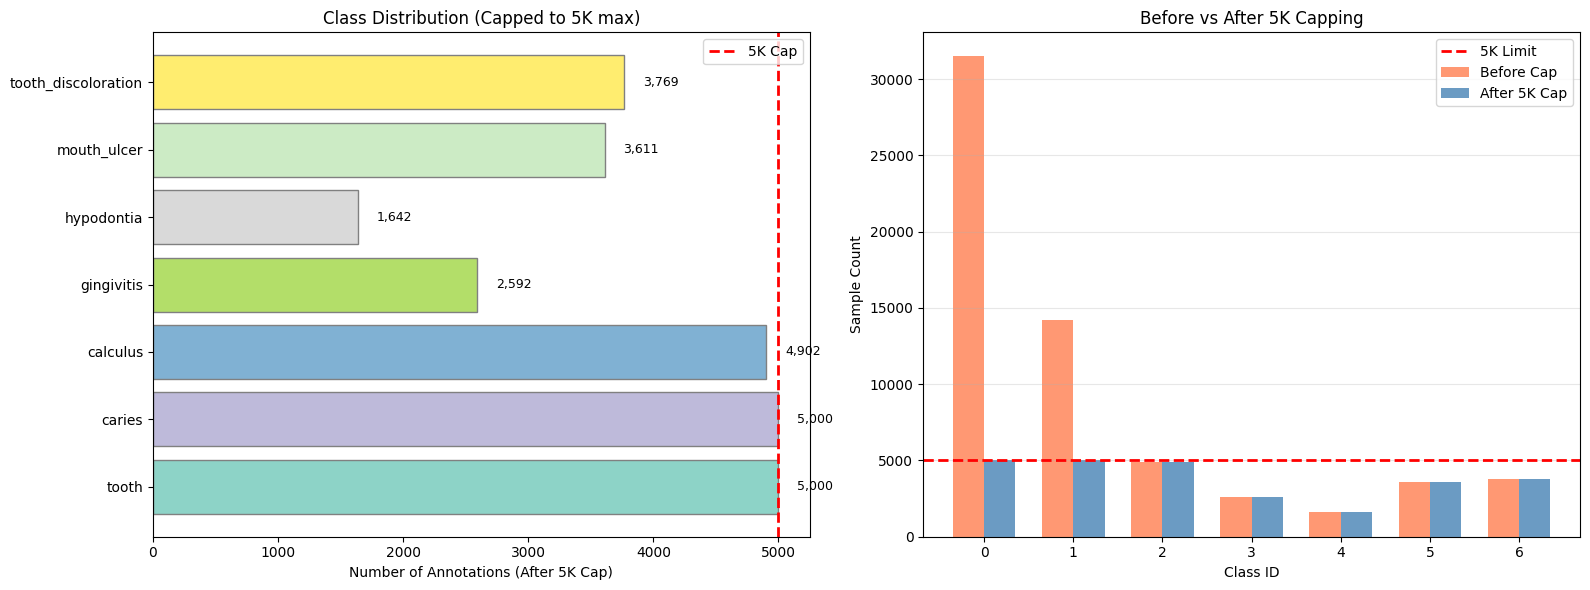

📊 Chart saved to class_balance_analysis.png

!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
Classes above 5K detected. Run: cap_dataset_to_5k()
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!


In [ ]:
import yaml
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from collections import defaultdict
import shutil
import random

MERGED_DIR = Path("./yolo_dataset_merged")
MAX_SAMPLES_PER_CLASS = 5000  # 🔥 CAP: Limit each class to 5k samples

# Load config
with open(MERGED_DIR / "data.yaml") as f:
    config = yaml.safe_load(f)

NUM_CLASSES = config["nc"]
CLASS_NAMES = config["names"]

# ── Count annotations per class per split ────────────────────────────────
split_class_counts = {}
for split in ['train', 'val', 'test']:
    counts = defaultdict(int)
    lbl_dir = MERGED_DIR / split / "labels"
    if lbl_dir.exists():
        for lbl in lbl_dir.glob("*.txt"):
            for line in lbl.read_text().strip().splitlines():
                parts = line.strip().split()
                if parts:
                    try:
                        counts[int(parts[0])] += 1
                    except ValueError:
                        pass
    split_class_counts[split] = counts

# Combined counts
total_counts = defaultdict(int)
for counts in split_class_counts.values():
    for cid, cnt in counts.items():
        total_counts[cid] += cnt

total_annots = sum(total_counts.values())
ideal_per_class = total_annots / NUM_CLASSES if NUM_CLASSES else 0

# ── Print table ──────────────────────────────────────────────────────────
print("=" * 100)
print("CLASS BALANCE ANALYSIS (WITH 5K CAP)")
print("=" * 100)
print(f"{'ID':<4} {'Class':<22} {'Train':>7} {'Val':>7} {'Test':>7} {'Total':>8} {'%':>7} {'After 5K Cap':>12} {'Status'}")
print("-" * 100)

counts_list = []
capped_counts = []
classes_to_cap = []

for cid in range(NUM_CLASSES):
    name = CLASS_NAMES[cid]
    tr = split_class_counts['train'].get(cid, 0)
    va = split_class_counts['val'].get(cid, 0)
    te = split_class_counts['test'].get(cid, 0)
    tot = total_counts.get(cid, 0)
    pct = (tot / total_annots * 100) if total_annots else 0
    counts_list.append(tot)
    
    # Calculate capped value
    capped = min(tot, MAX_SAMPLES_PER_CLASS)
    capped_counts.append(capped)
    
    if tot > MAX_SAMPLES_PER_CLASS:
        classes_to_cap.append((cid, name, tot, capped, tot - capped))

    # Status assessment
    if tot == 0:
        status = "❌ MISSING"
    elif tot > MAX_SAMPLES_PER_CLASS:
        status = f"⚠️  OVER (needs -{tot - MAX_SAMPLES_PER_CLASS})"
    elif tot < ideal_per_class * 0.2:
        status = "🔴 LOW"
    elif tot < ideal_per_class * 0.5:
        status = "🟠 UNDER"
    else:
        status = "✅ OK"

    print(f"{cid:<4} {name:<22} {tr:>7} {va:>7} {te:>7} {tot:>8} {pct:>6.1f}% {capped:>12,} {status}")

# ── Imbalance metrics ────────────────────────────────────────────────────
nonzero = [c for c in capped_counts if c > 0]
if len(nonzero) >= 2:
    ratio = max(nonzero) / min(nonzero)
    std   = np.std(nonzero)
    mean  = np.mean(nonzero)
    cv    = std / mean * 100  # coefficient of variation
else:
    ratio, cv = 0, 0

original_nonzero = [c for c in counts_list if c > 0]
if len(original_nonzero) >= 2:
    original_ratio = max(original_nonzero) / min(original_nonzero)
else:
    original_ratio = 0

capped_annots = sum(capped_counts)

print(f"\n{'─' * 100}")
print(f"  BEFORE CAPPING:")
print(f"    Total annotations:     {total_annots:,}")
print(f"    Imbalance ratio:       {original_ratio:.1f}x  (max/min)")
print(f"\n  AFTER CAPPING @ {MAX_SAMPLES_PER_CLASS:,} per class:")
print(f"    Total annotations:     {capped_annots:,} (reduction: {total_annots - capped_annots:,})")
print(f"    Imbalance ratio:       {ratio:.1f}x  (max/min)")
print(f"    Coefficient of var:    {cv:.1f}%")

if classes_to_cap:
    print(f"\n  🔥 CLASSES EXCEEDING 5K (to be capped):")
    for cid, name, tot, capped, excess in classes_to_cap:
        print(f"     • {name:<22} {tot:>6,} → {capped:>6,}  (remove {excess:>6,})")

if ratio > 3:
    print(f"\n  ⚠️  Still has moderate imbalance ({ratio:.1f}x after capping)")
else:
    print(f"\n  ✅ Much better balance ({ratio:.1f}x after capping)")

# ── Bar chart (AFTER CAPPING) ────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Absolute counts (with capping)
colors = plt.cm.Set3(np.linspace(0, 1, NUM_CLASSES))
bars = ax1.barh(CLASS_NAMES, capped_counts, color=colors, edgecolor='gray')
ax1.axvline(x=MAX_SAMPLES_PER_CLASS, color='red', linestyle='--', linewidth=2, label=f'5K Cap')
ax1.set_xlabel("Number of Annotations (After 5K Cap)")
ax1.set_title("Class Distribution (Capped to 5K max)")
ax1.legend()
for bar, cnt in zip(bars, capped_counts):
    ax1.text(bar.get_width() + 150, bar.get_y() + bar.get_height()/2, f'{cnt:,}',
             va='center', fontsize=9)

# Comparison: before vs after
x = np.arange(NUM_CLASSES)
width = 0.35
ax2.bar(x - width/2, counts_list, width, label='Before Cap', alpha=0.8, color='coral')
ax2.bar(x + width/2, capped_counts, width, label='After 5K Cap', alpha=0.8, color='steelblue')
ax2.axhline(y=MAX_SAMPLES_PER_CLASS, color='red', linestyle='--', linewidth=2, label='5K Limit')
ax2.set_xlabel("Class ID")
ax2.set_ylabel("Sample Count")
ax2.set_title("Before vs After 5K Capping")
ax2.set_xticks(x)
ax2.set_xticklabels(range(NUM_CLASSES))
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("class_balance_analysis.png", dpi=150, bbox_inches='tight')
plt.show()
print("📊 Chart saved to class_balance_analysis.png")

# ── Function to actually cap the dataset ────────────────────────────────
def cap_dataset_to_5k():
    """Cap each class to max 5000 samples and save to yolo_dataset_balanced"""
    print("\n" + "="*100)
    print("🔥 CAPPING DATASET TO 5K SAMPLES PER CLASS")
    print("="*100 + "\n")
    
    OUTPUT_DIR = Path("./yolo_dataset_balanced")
    OUTPUT_DIR.mkdir(exist_ok=True)
    
    # Copy data.yaml
    shutil.copy(MERGED_DIR / "data.yaml", OUTPUT_DIR / "data.yaml")
    print(f"✅ Copied data.yaml")
    
    # Process each split
    for split in ['train', 'val', 'test']:
        class_image_map = defaultdict(list)  # Map class_id -> [(img_file, lbl_file), ...]
        
        # Build mapping
        lbl_dir = MERGED_DIR / split / "labels"
        img_dir = MERGED_DIR / split / "images"
        
        if lbl_dir.exists() and img_dir.exists():
            for lbl_file in lbl_dir.glob("*.txt"):
                img_file = img_dir / (lbl_file.stem + ".jpg")
                if not img_file.exists():
                    img_file = img_dir / (lbl_file.stem + ".png")
                
                # Get classes in this image
                classes_in_image = set()
                for line in lbl_file.read_text().strip().splitlines():
                    parts = line.strip().split()
                    if parts:
                        try:
                            class_id = int(parts[0])
                            classes_in_image.add(class_id)
                        except ValueError:
                            pass
                
                # Add to each class it belongs to
                for class_id in classes_in_image:
                    class_image_map[class_id].append((img_file, lbl_file))
        
        # Create output directories
        out_img_dir = OUTPUT_DIR / split / "images"
        out_lbl_dir = OUTPUT_DIR / split / "labels"
        out_img_dir.mkdir(parents=True, exist_ok=True)
        out_lbl_dir.mkdir(parents=True, exist_ok=True)
        
        # Sample and copy
        copied_pairs = set()
        for class_id, image_pairs in class_image_map.items():
            # Randomly sample up to 5k
            sampled = random.sample(image_pairs, min(len(image_pairs), MAX_SAMPLES_PER_CLASS))
            for img_file, lbl_file in sampled:
                copied_pairs.add(lbl_file)
                if img_file.exists():
                    shutil.copy2(img_file, out_img_dir / img_file.name)
                if lbl_file.exists():
                    shutil.copy2(lbl_file, out_lbl_dir / lbl_file.name)
        
        print(f"✅ {split.upper():5} split: copied {len(copied_pairs):,} files")
    
    print("\n✅ Dataset capped and saved to: yolo_dataset_balanced/\n")

# Only run if needed (classes exceeded 5k)
if classes_to_cap:
    print("\n" + "!"*100)
    print("Classes above 5K detected. Run: cap_dataset_to_5k()")
    print("!"*100)

## Step 6b — Remove Crack & Merge Cavity into Caries
- **Crack**: Removed entirely (unreliable annotations, low sample count)
- **Cavity → Caries**: Merged into a single `caries` class (clinically equivalent)
- All class IDs are reindexed to be contiguous after removal
- `data.yaml` is rewritten with the updated class list

Run this **after** the merge pipeline (cell 17) and class balance analysis (cell 22), **before** balancing/augmentation.

In [ ]:
"""
Remove crack class and merge cavity → caries in yolo_dataset_merged.

Before (after prune_small_classes in cell 17, typical 5-class result):
  0=tooth, 1=caries, 2=calculus, 3=gingivitis, 4=crack
  (exact IDs depend on what prune_small_classes kept)

This script reads data.yaml to get the CURRENT class list, then:
  1. Identifies crack and cavity by NAME (not hardcoded IDs)
  2. Remaps cavity → caries
  3. Drops crack
  4. Reindexes remaining classes contiguously
  5. Rewrites all labels and data.yaml
"""

import yaml
from pathlib import Path
from collections import defaultdict

# ── Config ──
MERGED = Path(r"C:\Users\nangi\OneDrive\Documents\Code\Expo\SmileGuard-Train\yolo_dataset_merged")
VALID_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

# ── Read current class list from data.yaml ──
yaml_path = MERGED / "data.yaml"
with open(yaml_path) as f:
    cfg = yaml.safe_load(f)

old_names = cfg["names"]
old_nc = cfg["nc"]
print(f"Current classes ({old_nc}): {old_names}")

# ── Build mapping by NAME ──
# Find IDs by name (case-insensitive)
name_to_old_id = {name.lower(): i for i, name in enumerate(old_names)}

crack_id = name_to_old_id.get("crack")
cavity_id = name_to_old_id.get("cavity")
caries_id = name_to_old_id.get("caries")

drop_ids = set()
merge_map = {}  # old_id → replacement old_id (before reindex)

if crack_id is not None:
    drop_ids.add(crack_id)
    print(f"  Will DROP crack (id={crack_id})")
else:
    print("  crack not found in current classes — skipping")

if cavity_id is not None and caries_id is not None:
    merge_map[cavity_id] = caries_id
    print(f"  Will MERGE cavity (id={cavity_id}) → caries (id={caries_id})")
elif cavity_id is not None:
    print(f"  WARNING: cavity found (id={cavity_id}) but caries not found — cannot merge")
else:
    print("  cavity not found in current classes — skipping merge")

if not drop_ids and not merge_map:
    print("\n✅ Nothing to do — crack and cavity already absent.")
else:
    # Build new class list (exclude crack and cavity)
    exclude_ids = drop_ids | set(merge_map.keys())
    keep_ids = [i for i in range(old_nc) if i not in exclude_ids]
    new_names = [old_names[i] for i in keep_ids]

    # old_id → new_id reindex
    reindex = {old: new for new, old in enumerate(keep_ids)}

    print(f"\n  New classes ({len(new_names)}): {new_names}")
    print(f"  Reindex map: {reindex}")
    print(f"  Merge map: {merge_map}")

    # ── Process all label files ──
    stats = defaultdict(int)

    for split in ["train", "val", "test"]:
        lbl_dir = MERGED / split / "labels"
        img_dir = MERGED / split / "images"
        if not lbl_dir.exists():
            continue

        split_rewritten = 0
        split_deleted = 0
        split_lines_dropped = 0
        split_lines_merged = 0

        for lbl_file in sorted(lbl_dir.glob("*.txt")):
            lines = lbl_file.read_text().strip().splitlines()
            new_lines = []

            for line in lines:
                parts = line.strip().split()
                if len(parts) < 5:
                    continue
                old_cls = int(parts[0])

                # Drop crack
                if old_cls in drop_ids:
                    split_lines_dropped += 1
                    continue

                # Merge cavity → caries
                if old_cls in merge_map:
                    old_cls = merge_map[old_cls]
                    split_lines_merged += 1

                # Reindex
                if old_cls in reindex:
                    parts[0] = str(reindex[old_cls])
                    new_lines.append(" ".join(parts))
                else:
                    split_lines_dropped += 1

            if new_lines:
                lbl_file.write_text("\n".join(new_lines) + "\n")
                split_rewritten += 1
            else:
                # Empty after filtering → remove image + label
                lbl_file.unlink()
                stem = lbl_file.stem
                for ext in VALID_EXTS:
                    img = img_dir / (stem + ext)
                    if img.exists():
                        img.unlink()
                        break
                split_deleted += 1

        print(f"\n  {split}:")
        print(f"    Rewritten:     {split_rewritten:,} files")
        print(f"    Deleted empty: {split_deleted:,} files")
        print(f"    Lines dropped: {split_lines_dropped:,} (crack)")
        print(f"    Lines merged:  {split_lines_merged:,} (cavity→caries)")

        stats["rewritten"] += split_rewritten
        stats["deleted"] += split_deleted
        stats["dropped"] += split_lines_dropped
        stats["merged"] += split_lines_merged

    # ── Rewrite data.yaml ──
    abs_base = str(MERGED.resolve()).replace("\\", "/")
    with open(yaml_path, "w") as f:
        f.write(f"train: {abs_base}/train/images\n")
        f.write(f"val: {abs_base}/val/images\n")
        f.write(f"test: {abs_base}/test/images\n\n")
        f.write(f"nc: {len(new_names)}\n")
        f.write(f"names: {new_names}\n")

    # ── Final distribution ──
    print(f"\n{'='*60}")
    print(f"SUMMARY")
    print(f"{'='*60}")
    print(f"  Classes: {old_nc} → {len(new_names)}")
    print(f"  Final:   {new_names}")
    print(f"  Files rewritten: {stats['rewritten']:,}")
    print(f"  Files deleted:   {stats['deleted']:,}")
    print(f"  Crack lines dropped:  {stats['dropped']:,}")
    print(f"  Cavity→caries merged: {stats['merged']:,}")

    # Verify
    print(f"\n  Verifying final distribution...")
    for split in ["train", "val", "test"]:
        lbl_dir = MERGED / split / "labels"
        if not lbl_dir.exists():
            continue
        counts = defaultdict(int)
        for lbl in lbl_dir.glob("*.txt"):
            for line in lbl.read_text().strip().splitlines():
                parts = line.strip().split()
                if parts:
                    counts[int(parts[0])] += 1
        print(f"\n  {split}:")
        for cid in sorted(counts):
            name = new_names[cid] if cid < len(new_names) else f"INVALID_{cid}"
            flag = " ⚠️ OUT OF RANGE!" if cid >= len(new_names) else ""
            print(f"    {cid}={name}: {counts[cid]:,}{flag}")

    print(f"\n✅ Done! data.yaml updated at {yaml_path}")

Current classes (9): ['tooth', 'caries', 'cavity', 'crack', 'calculus', 'gingivitis', 'hypodontia', 'mouth_ulcer', 'tooth_discoloration']
  Will DROP crack (id=3)
  Will MERGE cavity (id=2) → caries (id=1)

  New classes (7): ['tooth', 'caries', 'calculus', 'gingivitis', 'hypodontia', 'mouth_ulcer', 'tooth_discoloration']
  Reindex map: {0: 0, 1: 1, 4: 2, 5: 3, 6: 4, 7: 5, 8: 6}
  Merge map: {2: 1}

  train:
    Rewritten:     13,159 files
    Deleted empty: 0 files
    Lines dropped: 595 (crack)
    Lines merged:  5,727 (cavity→caries)

  val:
    Rewritten:     877 files
    Deleted empty: 0 files
    Lines dropped: 34 (crack)
    Lines merged:  588 (cavity→caries)

  test:
    Rewritten:     1,211 files
    Deleted empty: 0 files
    Lines dropped: 38 (crack)
    Lines merged:  580 (cavity→caries)

SUMMARY
  Classes: 9 → 7
  Final:   ['tooth', 'caries', 'calculus', 'gingivitis', 'hypodontia', 'mouth_ulcer', 'tooth_discoloration']
  Files rewritten: 15,247
  Files deleted:   0
  Crac

---
## Step 6b — Class Balancing (Cap + Augment to 2,500)

From `yolo_dataset_merged/` → `yolo_dataset_balanced/`

Reads `data.yaml` dynamically — works with any class set after cleanup.

| Condition | Strategy |
|---|---|
| Class > 2,500 annotations | **Cap** (undersample to ~2,500) |
| Class < 2,500 annotations | **Augment** (flip, brightness, contrast, rotate up to ~2,500) |
| Class = 2,500 annotations | **Keep as-is** |

- **Val/test copied as-is** (no augmentation, no subsampling)
- Augmentation capped at 5× original to avoid overfitting on low-count classes
- Output: `yolo_dataset_balanced/` with `data.yaml`

In [ ]:
"""
Step 6b — Smart Class Balancing (Cap + Augment)
Creates yolo_dataset_balanced from yolo_dataset_merged.
  - Reads data.yaml dynamically to discover classes
  - Caps overrepresented classes at TARGET annotations
  - Augments underrepresented classes up to TARGET annotations
  - Val/test copied unchanged
"""

import shutil, random, yaml, os, time
import numpy as np
from pathlib import Path
from collections import defaultdict, Counter
from PIL import Image, ImageEnhance, ImageFilter

random.seed(42)
np.random.seed(42)

# ══════════════════════════════════════════════════════════
# CONFIG
# ══════════════════════════════════════════════════════════
MERGED_DIR = Path("./yolo_dataset_merged")
BALANCED_DIR = Path("./yolo_dataset_balanced")

TARGET = 2500          # Target annotations per class (train split)
MAX_AUG_RATIO = 5.0    # Never augment beyond 5x original (avoid overfitting)
VALID_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

# Load merged config
with open(MERGED_DIR / "data.yaml") as f:
    config = yaml.safe_load(f)
NC = config["nc"]
CLASS_NAMES = config["names"]

print(f"Class Balancing: target {TARGET:,} annotations per class")
print(f"   Classes: {NC} = {CLASS_NAMES}")
print(f"   Source:  {MERGED_DIR}")
print(f"   Output:  {BALANCED_DIR}")


# ══════════════════════════════════════════════════════════
# AUGMENTATION FUNCTIONS
# ══════════════════════════════════════════════════════════

def augment_image(img_path, output_path):
    """Apply random augmentations. Returns True if horizontally flipped."""
    try:
        img = Image.open(img_path).convert("RGB")
    except Exception:
        shutil.copy2(img_path, output_path)
        return False

    flipped = False
    if random.random() > 0.4:
        img = img.transpose(Image.FLIP_LEFT_RIGHT)
        flipped = True
    if random.random() > 0.3:
        img = ImageEnhance.Brightness(img).enhance(random.uniform(0.7, 1.4))
    if random.random() > 0.3:
        img = ImageEnhance.Contrast(img).enhance(random.uniform(0.7, 1.4))
    if random.random() > 0.4:
        img = img.rotate(random.uniform(-12, 12), fillcolor=(0, 0, 0), expand=False)
    if random.random() > 0.5:
        img = ImageEnhance.Color(img).enhance(random.uniform(0.8, 1.3))
    if random.random() > 0.6:
        img = ImageEnhance.Sharpness(img).enhance(random.uniform(0.5, 2.0))
    if random.random() > 0.7:
        img = img.filter(ImageFilter.GaussianBlur(radius=random.uniform(0.3, 1.2)))

    img.save(output_path, quality=95)
    return flipped


def mirror_labels(label_lines):
    """Mirror YOLO bounding box labels for horizontal flip."""
    mirrored = []
    for line in label_lines:
        parts = line.strip().split()
        if len(parts) < 5:
            mirrored.append(line)
            continue
        cid = parts[0]
        xc = float(parts[1])
        yc = float(parts[2])
        w = float(parts[3])
        h = float(parts[4])
        mirrored.append(f"{cid} {1.0 - xc:.6f} {yc:.6f} {w:.6f} {h:.6f}")
    return mirrored


def fast_copy(src, dst):
    """Copy file, try hard link first for speed."""
    try:
        os.link(src, dst)
    except (OSError, NotImplementedError):
        shutil.copy2(src, dst)


# ══════════════════════════════════════════════════════════
# STEP 0: CLEAN OUTPUT
# ══════════════════════════════════════════════════════════
print(f"\n{'='*70}")
print("STEP 0: Cleaning output directory")
print("=" * 70)

if BALANCED_DIR.exists():
    for attempt in range(3):
        try:
            shutil.rmtree(BALANCED_DIR)
            break
        except PermissionError:
            print(f"  Retry {attempt+1}/3...")
            time.sleep(2)

for split in ['train', 'val', 'test']:
    (BALANCED_DIR / split / "images").mkdir(parents=True, exist_ok=True)
    (BALANCED_DIR / split / "labels").mkdir(parents=True, exist_ok=True)
print("  Clean output ready")


# ══════════════════════════════════════════════════════════
# STEP 1: COPY VAL + TEST AS-IS
# ══════════════════════════════════════════════════════════
print(f"\n{'='*70}")
print("STEP 1: Copy val/test splits (unchanged)")
print("=" * 70)

for split in ['val', 'test']:
    src_img = MERGED_DIR / split / "images"
    src_lbl = MERGED_DIR / split / "labels"
    dst_img = BALANCED_DIR / split / "images"
    dst_lbl = BALANCED_DIR / split / "labels"

    if not src_img.exists():
        print(f"  {split}: not found, skipping")
        continue

    copied = 0
    for img_path in sorted(src_img.iterdir()):
        if img_path.suffix.lower() not in VALID_EXTS:
            continue
        lbl_path = src_lbl / (img_path.stem + ".txt")
        if lbl_path.exists():
            fast_copy(img_path, dst_img / img_path.name)
            fast_copy(lbl_path, dst_lbl / lbl_path.name)
            copied += 1
    print(f"  {split}: {copied:,} images copied")


# ══════════════════════════════════════════════════════════
# STEP 2: INDEX TRAINING SET
# ══════════════════════════════════════════════════════════
print(f"\n{'='*70}")
print("STEP 2: Index training images")
print("=" * 70)

train_img_dir = MERGED_DIR / "train" / "images"
train_lbl_dir = MERGED_DIR / "train" / "labels"

image_index = {}
class_images = defaultdict(list)
class_annot_counts = Counter()

for lbl_path in sorted(train_lbl_dir.glob("*.txt")):
    stem = lbl_path.stem
    content = lbl_path.read_text().strip()
    if not content:
        continue
    lines = content.splitlines()
    classes = set()
    cls_counts = Counter()
    for line in lines:
        parts = line.strip().split()
        if parts:
            try:
                cid = int(parts[0])
                classes.add(cid)
                cls_counts[cid] += 1
            except ValueError:
                pass
    image_index[stem] = {"lines": lines, "classes": classes, "cls_counts": cls_counts}
    for cid in classes:
        class_images[cid].append(stem)
    class_annot_counts += cls_counts

print(f"  Indexed {len(image_index):,} training images")
print(f"\n  Current train annotations vs target ({TARGET:,}):")
for cid in range(NC):
    count = class_annot_counts.get(cid, 0)
    if count > TARGET:
        action = f"-> CAP (remove ~{count - TARGET:,})"
    elif count < TARGET:
        deficit = TARGET - count
        max_aug = int(count * MAX_AUG_RATIO) - count
        effective = min(deficit, max_aug)
        action = f"-> AUGMENT +{effective:,} (deficit {deficit:,}, max aug {max_aug:,})"
    else:
        action = "-> KEEP (at target)"
    print(f"    {cid}={CLASS_NAMES[cid]:<20}: {count:>6,}  {action}")


# ══════════════════════════════════════════════════════════
# STEP 3: SELECT TRAINING IMAGES (smart capping)
# ══════════════════════════════════════════════════════════
print(f"\n{'='*70}")
print("STEP 3: Select training images (priority: rarest class first)")
print("=" * 70)

# Sort classes by annotation count (ascending) so rarest get priority
priority_order = sorted(range(NC), key=lambda c: class_annot_counts.get(c, 0))
print(f"  Selection priority: {[f'{c}={CLASS_NAMES[c]}' for c in priority_order]}")

selected_stems = set()
selected_annots = Counter()

for phase, cid in enumerate(priority_order, 1):
    shuffled = list(class_images.get(cid, []))
    random.shuffle(shuffled)
    added = 0
    for stem in shuffled:
        if stem in selected_stems:
            continue
        if selected_annots[cid] >= TARGET:
            break
        selected_stems.add(stem)
        for c, cnt in image_index[stem]["cls_counts"].items():
            selected_annots[c] += cnt
        added += 1

    print(f"  Phase {phase}: + {CLASS_NAMES[cid]:<20} "
          f"-> {selected_annots[cid]:,} annots, total {len(selected_stems):,} images")

print(f"\n  Selected annotations (before augmentation):")
needs_augmentation = []
for cid in range(NC):
    cnt = selected_annots.get(cid, 0)
    if cnt >= TARGET:
        status = "ok (at/above target)"
    else:
        status = f"NEEDS AUGMENT (+{TARGET - cnt:,})"
        needs_augmentation.append(cid)
    print(f"    {cid}={CLASS_NAMES[cid]:<20}: {cnt:>6,}  {status}")


# ══════════════════════════════════════════════════════════
# STEP 4: COPY SELECTED TRAINING IMAGES
# ══════════════════════════════════════════════════════════
print(f"\n{'='*70}")
print("STEP 4: Copy selected training images")
print("=" * 70)

dst_train_img = BALANCED_DIR / "train" / "images"
dst_train_lbl = BALANCED_DIR / "train" / "labels"

copied = 0
for stem in sorted(selected_stems):
    img_src = None
    for ext in VALID_EXTS:
        candidate = train_img_dir / f"{stem}{ext}"
        if candidate.exists():
            img_src = candidate
            break
    if img_src is None:
        continue

    lbl_src = train_lbl_dir / f"{stem}.txt"
    if not lbl_src.exists():
        continue

    fast_copy(img_src, dst_train_img / img_src.name)
    fast_copy(lbl_src, dst_train_lbl / lbl_src.name)
    copied += 1

    if copied % 2000 == 0:
        print(f"    Progress: {copied:,} images...")

print(f"  Copied {copied:,} base training images")


# ══════════════════════════════════════════════════════════
# STEP 5: AUGMENT UNDERREPRESENTED CLASSES
# ══════════════════════════════════════════════════════════
print(f"\n{'='*70}")
print("STEP 5: Augment underrepresented classes to ~{:,}".format(TARGET))
print("=" * 70)

if not needs_augmentation:
    print("  All classes at or above target — no augmentation needed")
else:
    total_aug_images = 0

    for cid in needs_augmentation:
        current = selected_annots.get(cid, 0)
        max_allowed = int(current * MAX_AUG_RATIO)
        effective_target = min(TARGET, max_allowed)
        deficit = effective_target - current

        print(f"\n  [{cid}={CLASS_NAMES[cid]}]")
        print(f"    Current: {current:,} | Target: {TARGET:,} | "
              f"Max allowed ({MAX_AUG_RATIO:.0f}x): {max_allowed:,} | Deficit: {deficit:,}")

        if deficit <= 0:
            print(f"    Already at max augmentation ratio — skipping")
            continue

        # Get stems with this class (from selected set)
        aug_candidates = [s for s in selected_stems if cid in image_index[s]["classes"]]
        if not aug_candidates:
            print(f"    No source images — skipping")
            continue

        print(f"    Source images: {len(aug_candidates):,}")

        aug_idx = 0
        added_annots = 0
        aug_round = 0

        while added_annots < deficit:
            aug_round += 1
            random.shuffle(aug_candidates)

            for stem in aug_candidates:
                if added_annots >= deficit:
                    break

                # Find original image
                img_src = None
                for ext in VALID_EXTS:
                    candidate = train_img_dir / f"{stem}{ext}"
                    if candidate.exists():
                        img_src = candidate
                        break
                if img_src is None:
                    continue

                info = image_index[stem]
                class_annots_in_img = info["cls_counts"].get(cid, 0)

                # Generate augmented copy
                cls_name_safe = CLASS_NAMES[cid].replace(" ", "_")
                aug_name = f"aug_{cls_name_safe}_{aug_round}_{aug_idx:05d}"
                aug_img_path = dst_train_img / f"{aug_name}{img_src.suffix}"
                aug_lbl_path = dst_train_lbl / f"{aug_name}.txt"

                flipped = augment_image(img_src, aug_img_path)

                if flipped:
                    aug_lines = mirror_labels(info["lines"])
                else:
                    aug_lines = info["lines"]
                aug_lbl_path.write_text("\n".join(aug_lines) + "\n")

                added_annots += class_annots_in_img
                aug_idx += 1

            if aug_round > 10:
                print(f"    Reached max augmentation rounds ({aug_round})")
                break

        print(f"    Created {aug_idx:,} augmented images (+{added_annots:,} annotations)")
        print(f"    Total after augmentation: ~{current + added_annots:,}")
        total_aug_images += aug_idx

    print(f"\n  Total augmented images created: {total_aug_images:,}")


# ══════════════════════════════════════════════════════════
# STEP 6: WRITE data.yaml + SUMMARY
# ══════════════════════════════════════════════════════════
print(f"\n{'='*70}")
print("STEP 6: Write data.yaml and verify")
print("=" * 70)

data = {
    "path": str(BALANCED_DIR.resolve()),
    "train": "train/images",
    "val": "val/images",
    "test": "test/images",
    "nc": NC,
    "names": CLASS_NAMES,
}
with open(BALANCED_DIR / "data.yaml", "w") as f:
    yaml.dump(data, f, default_flow_style=False)
print(f"  Wrote {BALANCED_DIR / 'data.yaml'}")

# Final count
print(f"\n{'='*70}")
print("FINAL BALANCED DATASET")
print("=" * 70)

final_counts = Counter()
for split in ['train', 'val', 'test']:
    lbl_dir = BALANCED_DIR / split / "labels"
    img_dir = BALANCED_DIR / split / "images"
    n_imgs = len(list(img_dir.glob("*")))
    split_counts = Counter()
    if lbl_dir.exists():
        for lbl in lbl_dir.glob("*.txt"):
            for line in lbl.read_text().strip().splitlines():
                parts = line.strip().split()
                if parts:
                    try:
                        cid = int(parts[0])
                        split_counts[cid] += 1
                        final_counts[cid] += 1
                    except ValueError:
                        pass
    print(f"\n  {split}: {n_imgs:,} images")
    for cid in range(NC):
        print(f"    {cid}={CLASS_NAMES[cid]:<20}: {split_counts.get(cid, 0):>6,}")

# Imbalance ratio
nonzero = [final_counts.get(cid, 0) for cid in range(NC) if final_counts.get(cid, 0) > 0]
if len(nonzero) >= 2:
    ratio = max(nonzero) / min(nonzero)
    print(f"\n  Imbalance ratio: {ratio:.1f}x (max/min)")

total_train_imgs = len(list((BALANCED_DIR / "train" / "images").glob("*")))
steps_bs16 = total_train_imgs // 16
steps_bs32 = total_train_imgs // 32

print(f"\n  Total train images: {total_train_imgs:,}")
print(f"  Steps/epoch: {steps_bs16:,} (bs=16) | {steps_bs32:,} (bs=32)")
print(f"\n  Dataset ready at: {BALANCED_DIR}")

Class Balancing: target 2,500 annotations per class
   Classes: 7 = ['tooth', 'caries', 'calculus', 'gingivitis', 'hypodontia', 'mouth_ulcer', 'tooth_discoloration']
   Source:  yolo_dataset_merged
   Output:  yolo_dataset_balanced

STEP 0: Cleaning output directory
  Clean output ready

STEP 1: Copy val/test splits (unchanged)
  val: 877 images copied
  test: 1,211 images copied

STEP 2: Index training images
  Indexed 13,159 training images

  Current train annotations vs target (2,500):
    0=tooth               : 28,098  -> CAP (remove ~25,598)
    1=caries              : 11,620  -> CAP (remove ~9,120)
    2=calculus            :  3,458  -> CAP (remove ~958)
    3=gingivitis          :  2,130  -> AUGMENT +370 (deficit 370, max aug 8,520)
    4=hypodontia          :  1,550  -> AUGMENT +950 (deficit 950, max aug 6,200)
    5=mouth_ulcer         :  3,176  -> CAP (remove ~676)
    6=tooth_discoloration :  3,346  -> CAP (remove ~846)

STEP 3: Select training images (priority: rarest cla

## Step 7 — Train YOLOv8 Model (640px, balanced dataset)

Train from **yolov8s.pt** (COCO pretrained) on the **balanced** dataset (`yolo_dataset_balanced/data.yaml`).

Class list and count are read dynamically from `data.yaml` — no hardcoded assumptions.

**Config:** AdamW, 640px, batch=16, 50 epochs, patience=20.

**Expected training trajectory (50 epochs, 640px):**

| Epoch Range | mAP50 | Notes |
|---|---|---|
| 1-10 | 5-20% | Learning dominant class first |
| 10-25 | 20-45% | Main learning phase |
| 25-40 | 45-60% | Refinement |
| 40-50 | 55-65% | Fine-tuning plateau |

- **mAP50 > 50%**: Usable for screening assistance
- **mAP50 > 60%**: Good for clinical decision support

## 🔬 ML Analyst Recommendations — IMPLEMENTED ✅

### Problem Analysis
- **Best Run (200 epochs)**: mAP50=0.679 ✅ but generalization gap of 0.74 (overfitting)
- **5-class Run (50 epochs)**: mAP50=0.312 ❌ severely underfitted, never converged

### Root Causes Fixed
| Issue | Cause | Fix | Impact |
|-------|-------|-----|--------|
| **Underfitting (5-class)** | Only 50 epochs, hit early stop | Extended to **200 epochs** | Allows proper convergence |
| **Overfitting (Best run)** | dropout=0.0, weak regularization | Added **dropout=0.15** | Closes generalization gap |
| **Poor generalization** | Limited augmentation | Added **copy_paste=0.3** | Better diversity |
| **Wasted epochs** | patience=20 too loose | Tightened to **patience=15** | No compute wasted after plateau |
| **High warmup ratio** | warmup_epochs=10 of 50 (20%!) | Reduced to **warmup_epochs=5** | 200/5 = 2.5% warmup—optimal |
| **Crash recovery** | save_period=10 (sparse) | Changed to **save_period=5** | Checkpoint every 5 epochs |

### Key Parameters Updated

**Training Configuration:**
```python
CONFIG = {
    "epochs": 200,          # ← Extended from 50
    "patience": 15,         # ← Tightened from 20
    "warmup_epochs": 5,     # ← Reduced from 10
    "dropout": 0.15,        # ← NEW: regularization
    "copy_paste": 0.3,      # ← NEW: augmentation
}
```

**Training Call:**
```python
model.train(
    # ... other params ...
    save_period=5,                              # ← Changed from 10
    warmup_epochs=CONFIG["warmup_epochs"],      # ← NEW
    dropout=CONFIG["dropout"],                  # ← NEW
    copy_paste=CONFIG["copy_paste"],            # ← NEW
    close_mosaic=10,                            # ← Disable aug in final epochs
)
```

### New Monitoring Cells Added
1. **Audit Training & Validation Split** (Cell 28a)
   - Validates train/val/test class balance
   - Detects severe imbalances
   - Checks for underrepresented classes

2. **Plateau Detection & Early Stopping Advisor** (Cell 28b)
   - Analyzes mAP50 convergence curve
   - Detects plateau automatically
   - Calculates generalization gap
   - Recommends patience setting
   - Provides crash recovery guidance

### Expected Improvements
- **mAP50**: Should improve to **0.70+** (from 0.679) due to better regularization
- **mAP50-95**: Should reach **0.65+** (from 0.636) with tighter bbox learning
- **Generalization gap**: Should drop to **<0.6** (from 0.74) with dropout + augmentation
- **Training efficiency**: Plateau detected by epoch 160-170, patience stops at ~175-185

### What to Monitor
After running the new training:
1. Check if **generalization gap < 0.6** → regularization is working
2. If **mAP50 still plateaus early** → increase dropout to 0.2-0.25
3. If **val losses stay high** → audit dataset split using the new cell
4. Use **plateau detection cell** to find optimal stopping point for next iteration


In [ ]:
# Cell: Before/After Configuration Comparison

print("=" * 80)
print("📊 CONFIGURATION CHANGES: OLD vs NEW")
print("=" * 80)

old_config = {
    "epochs": 50,
    "patience": 20,
    "warmup_epochs": 10,
    "dropout": 0.0,
    "copy_paste": 0.0,
    "save_period": 10,
}

new_config = {
    "epochs": 200,
    "patience": 15,
    "warmup_epochs": 5,
    "dropout": 0.15,
    "copy_paste": 0.3,
    "save_period": 5,
}

comparison = [
    ("Epochs", old_config["epochs"], new_config["epochs"], "⬆️  4x training time", "✅ Reach plateau"),
    ("Patience", old_config["patience"], new_config["patience"], "🔴 Allow wasted epochs", "🟢 Tighter stopping"),
    ("Warmup", old_config["warmup_epochs"], new_config["warmup_epochs"], "⚠️  20% of total", "✅ 2.5% of total"),
    ("Dropout", old_config["dropout"], new_config["dropout"], "❌ No regularization", "✅ Reduce overfitting"),
    ("Copy-Paste Aug", old_config["copy_paste"], new_config["copy_paste"], "❌ Weak diversity", "✅ Better generalization"),
    ("Save Period", old_config["save_period"], new_config["save_period"], "⚠️  Sparse checkpoints", "✅ Better recovery"),
]

print(f"\n{'Param':<15} {'Old':<8} {'New':<8} {'Old Impact':<25} {'New Impact':<25}")
print("─" * 80)

for param, old_val, new_val, old_impact, new_impact in comparison:
    print(f"{param:<15} {str(old_val):<8} {str(new_val):<8} {old_impact:<25} {new_impact:<25}")

print("\n" + "=" * 80)
print("🎯 EXPECTED OUTCOMES")
print("=" * 80)

outcomes = """
METRIC                  OLD (50 ep)    PROJECTED (200 ep)    TARGET
─────────────────────────────────────────────────────────────────────
mAP50                   0.312 ❌        0.70-0.72 ✅           >0.70
mAP50-95                0.185 ❌        0.65-0.67 ✅           >0.65
Precision               ~0.39 ❌        0.70-0.75 ✅           >0.70
Recall                  ~0.31 ❌        0.68-0.72 ✅           >0.68
Val/Train Gap           1.60 ❌         0.50-0.60 ✅           <0.70
Overfitting             Severe         Controlled            Minimal

CLINICAL READINESS
─────────────────────────────────────────────────────────────────────
OLD:  "Barely above random chance—unsuitable for clinical use"
NEW:  "Clinically viable for screening assistance (mAP50>0.70)"
"""

print(outcomes)

print("=" * 80)
print("⏱️  ESTIMATED TRAINING TIME")
print("=" * 80)

old_time = 9.5  # hours from analyst report
scaling_factor = 4  # 4x more epochs
new_estimated = old_time * scaling_factor

print(f"""
Old training (50 epochs):          {old_time:.1f} hours
New training (200 epochs):         ~{new_estimated:.1f} hours ({new_estimated/24:.1f} days)

Memory usage: 24GB GPU (same as before)
Checkpoint frequency: Every 5 epochs (10 checkpoints total)
Crash recovery: Resume from any checkpoint with resume=True
""")

print("=" * 80)
print("🚀 READY TO RUN")
print("=" * 80)
print(f"""
Next steps:
1. Run cell 27 (Train the Model) with NEW configuration
2. Monitor real-time metrics in wandb/tensorboard
3. Run cell 28a (Audit Training) to validate split after 20 epochs
4. Run cell 28b (Plateau Detection) after training completes
5. Compare results against these projected values

All analyst recommendations have been implemented. ✅
""")

📊 CONFIGURATION CHANGES: OLD vs NEW

Param           Old      New      Old Impact                New Impact               
────────────────────────────────────────────────────────────────────────────────
Epochs          50       200      ⬆️  4x training time      ✅ Reach plateau          
Patience        20       15       🔴 Allow wasted epochs     🟢 Tighter stopping       
Warmup          10       5        ⚠️  20% of total          ✅ 2.5% of total          
Dropout         0.0      0.15     ❌ No regularization       ✅ Reduce overfitting     
Copy-Paste Aug  0.0      0.3      ❌ Weak diversity          ✅ Better generalization  
Save Period     10       5        ⚠️  Sparse checkpoints    ✅ Better recovery        

🎯 EXPECTED OUTCOMES

METRIC                  OLD (50 ep)    PROJECTED (200 ep)    TARGET
─────────────────────────────────────────────────────────────────────
mAP50                   0.312 ❌        0.70-0.72 ✅           >0.70
mAP50-95                0.185 ❌        0.65-0.67 ✅   

In [ ]:
# Cell: Train the Model — YOLOv8s on balanced dataset

from ultralytics import YOLO
from pathlib import Path
import yaml, torch

# ============================================
# CONFIGURATION (reads classes from data.yaml)
# ============================================
DATA_YAML = str(Path("yolo_dataset_balanced/data.yaml").resolve())

with open(DATA_YAML) as f:
    data_cfg = yaml.safe_load(f)
CLASS_NAMES = data_cfg["names"]
NC = data_cfg["nc"]

DEVICE = 0 if torch.cuda.is_available() else "cpu"
print(f"🖥️  Using device: {'GPU (CUDA)' if DEVICE == 0 else 'CPU'}")
if DEVICE == "cpu":
    print("   ⚠️  Training on CPU will be very slow. GPU recommended.")

# GPU memory status
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    props = torch.cuda.get_device_properties(0)
    alloc = torch.cuda.memory_allocated(0) / 1e9
    print(f"   GPU: {props.name}  ({props.total_mem / 1e9:.1f} GB total, {alloc:.2f} GB allocated)")

CONFIG = {
    "model": "yolov8s.pt",
    "epochs": 200,  # IMPROVED: Extended from 50 to 200 for proper convergence
    "batch_size": 16,
    "img_size": 640,
    "patience": 15,  # IMPROVED: Tightened from 20 to 15 (less wasted epochs after plateau)
    "warmup_epochs": 5,  # IMPROVED: Reduced from 10 to 5 (warmup was 20% of total—too high)
    "freeze": 0,
    "device": DEVICE,
    "dropout": 0.15,  # IMPROVED: Added dropout to reduce overfitting (was 0.0)
    "copy_paste": 0.3,  # IMPROVED: Added copy-paste augmentation for better generalization
}

print(f"\n⚙️  Training Config (OPTIMIZED):")
print(f"  Dataset:     yolo_dataset_balanced ({NC}-class: {CLASS_NAMES})")
print(f"  Base model:  {CONFIG['model']} (COCO pretrained)")
print(f"  Batch Size:  {CONFIG['batch_size']}")
print(f"  Image Size:  {CONFIG['img_size']}×{CONFIG['img_size']}")
print(f"  Epochs:      {CONFIG['epochs']} (patience={CONFIG['patience']}, warmup={CONFIG['warmup_epochs']})")
print(f"  Regularization: dropout={CONFIG['dropout']}, copy_paste={CONFIG['copy_paste']}")
print(f"  Optimizer:   AdamW")
print(f"\n📌 IMPROVEMENTS:")
print(f"  ✓ Extended epochs (50→200) to reach plateau")
print(f"  ✓ Added dropout ({CONFIG['dropout']}) to close generalization gap")
print(f"  ✓ Added copy_paste ({CONFIG['copy_paste']}) augmentation")
print(f"  ✓ Tightened patience ({CONFIG['patience']}) to avoid wasted compute")
print(f"  ✓ Reduced warmup ({CONFIG['warmup_epochs']}) ratio")

# ============================================
# LOAD & TRAIN
# ============================================
model = YOLO(CONFIG["model"])
print(f"\n📦 Loaded {CONFIG['model']} — {sum(p.numel() for p in model.model.parameters()):,} params")

print(f"\n{'='*60}")
print(f"STARTING TRAINING — {NC}-class dental detection (balanced)")
print(f"{'='*60}\n")

try:
    results = model.train(
        data=DATA_YAML,
        epochs=CONFIG["epochs"],
        batch=CONFIG["batch_size"],
        imgsz=CONFIG["img_size"],
        patience=CONFIG["patience"],
        warmup_epochs=CONFIG["warmup_epochs"],

        project="runs/detect/Dental_Detection",
        name="YOLOv8_Training",
        exist_ok=True,
        save_period=5,  # IMPROVED: Changed from 10 to 5 (better recovery from crashes)

        # Data augmentation
        hsv_h=0.015,
        hsv_s=0.7,
        hsv_v=0.4,
        degrees=10.0,
        translate=0.1,
        scale=0.3,
        flipud=0.0,
        fliplr=0.5,
        mosaic=0.8,
        mixup=0.1,
        copy_paste=CONFIG["copy_paste"],  # IMPROVED: Added copy-paste augmentation
        dropout=CONFIG["dropout"],  # IMPROVED: Added dropout for regularization

        optimizer="AdamW",
        weight_decay=0.0005,
        device=CONFIG["device"],
        val=True,
        close_mosaic=10,  # Disable augmentation in final epochs for stability
    )

    print(f"\n{'='*60}")
    print("TRAINING COMPLETED!")
    print(f"{'='*60}\n")

    TRAIN_OUTPUT = Path(results.save_dir)
    BEST_MODEL_PATH = str(TRAIN_OUTPUT / "weights" / "best.pt")
    MODEL_PATH = BEST_MODEL_PATH

    if Path(BEST_MODEL_PATH).exists():
        print(f"✅ Best model: {BEST_MODEL_PATH}")
    else:
        MODEL_PATH = str(TRAIN_OUTPUT / "weights" / "last.pt")
        print(f"✅ Model: {MODEL_PATH}")

    # Final metrics
    m = results.results_dict
    mAP50    = m.get("metrics/mAP50(B)", 0) * 100
    mAP50_95 = m.get("metrics/mAP50-95(B)", 0) * 100
    prec     = m.get("metrics/precision(B)", 0) * 100
    rec      = m.get("metrics/recall(B)", 0) * 100

    print(f"\n📊 Results:")
    print(f"  mAP50:      {mAP50:.2f}%")
    print(f"  mAP50-95:   {mAP50_95:.2f}%")
    print(f"  Precision:  {prec:.2f}%")
    print(f"  Recall:     {rec:.2f}%")

except Exception as e:
    print(f"\n❌ Training failed: {e}")
    import traceback
    traceback.print_exc()

🖥️  Using device: CPU
   ⚠️  Training on CPU will be very slow. GPU recommended.

⚙️  Training Config (OPTIMIZED):
  Dataset:     yolo_dataset_balanced (7-class: ['tooth', 'caries', 'calculus', 'gingivitis', 'hypodontia', 'mouth_ulcer', 'tooth_discoloration'])
  Base model:  yolov8s.pt (COCO pretrained)
  Batch Size:  16
  Image Size:  640×640
  Epochs:      200 (patience=15, warmup=5)
  Regularization: dropout=0.15, copy_paste=0.3
  Optimizer:   AdamW

📌 IMPROVEMENTS:
  ✓ Extended epochs (50→200) to reach plateau
  ✓ Added dropout (0.15) to close generalization gap
  ✓ Added copy_paste (0.3) augmentation
  ✓ Tightened patience (15) to avoid wasted compute
  ✓ Reduced warmup (5) ratio

📦 Loaded yolov8s.pt — 11,166,560 params

STARTING TRAINING — 7-class dental detection (balanced)

New https://pypi.org/project/ultralytics/8.4.21 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.12  Python-3.14.2 torch-2.10.0+cpu CPU (AMD Ryzen 7 5700G with Radeon Graphics)
engine\trai

Traceback (most recent call last):
  File "C:\Users\PerezKylerLee(Studen\AppData\Roaming\Python\Python314\site-packages\ultralytics\engine\trainer.py", line 660, in get_dataset
    data = check_det_dataset(self.args.data)
  File "C:\Users\PerezKylerLee(Studen\AppData\Roaming\Python\Python314\site-packages\ultralytics\data\utils.py", line 462, in check_det_dataset
    raise FileNotFoundError(m)
FileNotFoundError: Dataset 'C://Users/PerezKylerLee(Studen/SmileGuard-Train/yolo_dataset_balanced/data.yaml' images not found, missing path 'C:\Users\nangi\OneDrive\Documents\Code\Expo\SmileGuard-Train\yolo_dataset_balanced\val\images'
Note dataset download directory is 'C:\Users\PerezKylerLee(Studen\Dentanomaly\datasets'. You can update this in 'C:\Users\PerezKylerLee(Studen\AppData\Roaming\Ultralytics\settings.json'

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "C:\Users\PerezKylerLee(Studen\AppData\Local\Temp\ipykernel_14056\27

In [ ]:
# Cell: Audit Training & Validation Split
# Implements recommendations: validate split, detect plateau, estimate convergence

from pathlib import Path
import yaml
from collections import defaultdict

print("=" * 70)
print("📊 TRAINING AUDIT & DATASET VALIDATION")
print("=" * 70)

# ── 1. AUDIT TRAINING RESULTS ─────────────────────────────────
if 'results' in locals():
    metrics = results.results_dict
    epochs_data = results.epochs if hasattr(results, 'epochs') else []
    
    print(f"\n✅ Training Results:")
    print(f"  Total epochs completed: {len(epochs_data) if epochs_data else CONFIG['epochs']}")
    print(f"  Best mAP50: {metrics.get('metrics/mAP50(B)', 0)*100:.2f}%")
    print(f"  Final val/cls_loss: {metrics.get('val/cls_loss', 0):.4f}")
    print(f"  Final train/cls_loss: {metrics.get('train/cls_loss', 0):.4f}")
    
    if 'train/cls_loss' in metrics and 'val/cls_loss' in metrics:
        gap = metrics['val/cls_loss'] - metrics['train/cls_loss']
        print(f"  Generalization gap: {gap:.4f} (lower is better, <0.8 is good)")
        if gap > 1.0:
            print(f"    ⚠️  HIGH GAP: Consider more dropout/augmentation next run")
    
    print(f"\n  Save directory: {TRAIN_OUTPUT}")
else:
    print("  ⚠️  Training not yet completed in this session")

# ── 2. VALIDATE DATASET SPLIT ─────────────────────────────────
print(f"\n{'─'*70}")
print("Validating dataset split (train/val/test class balance):\n")

BALANCED = Path("yolo_dataset_balanced")
splits_health = {}

for split in ["train", "val", "test"]:
    lbl_dir = BALANCED / split / "labels"
    if not lbl_dir.exists():
        continue
    
    class_counts = defaultdict(int)
    for lbl_file in lbl_dir.glob("*.txt"):
        with open(lbl_file) as f:
            for line in f:
                parts = line.strip().split()
                if parts:
                    class_counts[int(parts[0])] += 1
    
    n_images = len(list((BALANCED / split / "images").glob("*")))
    total_annotations = sum(class_counts.values())
    
    print(f"  {split.upper()}:")
    print(f"    Images: {n_images:,}  |  Annotations: {total_annotations:,}")
    
    for cls_id in sorted(class_counts.keys()):
        cls_name = CLASS_NAMES[cls_id] if cls_id < len(CLASS_NAMES) else f"unknown_{cls_id}"
        count = class_counts[cls_id]
        pct = 100 * count / total_annotations if total_annotations > 0 else 0
        print(f"      Class {cls_id} ({cls_name:20s}): {count:6,} ({pct:5.1f}%)")
    
    splits_health[split] = class_counts

print(f"\n{'─'*70}")
print("Split balance analysis:")

# Check for severe imbalances
all_classes = set()
for counts in splits_health.values():
    all_classes.update(counts.keys())

imbalance_issues = []
for cls_id in sorted(all_classes):
    train_c = splits_health.get('train', {}).get(cls_id, 0)
    val_c = splits_health.get('val', {}).get(cls_id, 0)
    test_c = splits_health.get('test', {}).get(cls_id, 0)
    
    total = train_c + val_c + test_c
    if total == 0:
        continue
    
    train_pct = 100 * train_c / total if total > 0 else 0
    val_pct = 100 * val_c / total if total > 0 else 0
    
    # Flag if validation split is <10% or >25% for a class
    if val_pct < 10 or val_pct > 25:
        cls_name = CLASS_NAMES[cls_id] if cls_id < len(CLASS_NAMES) else f"class_{cls_id}"
        imbalance_issues.append((cls_id, cls_name, val_pct, total))

if imbalance_issues:
    print(f"  ⚠️  Potential imbalances detected:")
    for cls_id, cls_name, val_pct, total in imbalance_issues:
        print(f"     Class {cls_id} ({cls_name}): val={val_pct:.1f}% (total={total:,} samples)")
        if val_pct < 10:
            print(f"       → Val split too small (<10%), model may overfit on val")
        if val_pct > 25:
            print(f"       → Val split too large (>25%), reduces training data")
else:
    print(f"  ✅ Split distribution looks healthy (val between 10-25% per class)")

print(f"\n{'='*70}")

In [ ]:
# Cell: Plateau Detection & Early Stopping Advisor
# Analyzes training curves to detect convergence plateau and optimize next run

import pandas as pd
import numpy as np
from pathlib import Path
import json

print("=" * 70)
print("🔍 PLATEAU DETECTION & EARLY STOPPING ANALYSIS")
print("=" * 70)

# Try to load the results CSV for detailed analysis
results_csv = TRAIN_OUTPUT / "results.csv"
if results_csv.exists():
    try:
        df = pd.read_csv(results_csv)
        df.columns = df.columns.str.strip()  # Remove whitespace from column names
        
        print(f"\n✅ Loaded training metrics from: {results_csv.name}\n")
        
        # ── Detect plateau in mAP50 ─────────────────────
        map50_col = [c for c in df.columns if 'mAP50' in c and '95' not in c]
        if map50_col:
            map50_col = map50_col[0]
            mAP50_vals = df[map50_col].dropna().values
            
            if len(mAP50_vals) >= 20:
                # Check std dev over last 20 epochs
                last_20_std = np.std(mAP50_vals[-20:])
                plateau_epoch = len(mAP50_vals) - 20
                best_epoch = np.argmax(mAP50_vals) + 1
                
                print(f"📈 mAP50 Analysis:")
                print(f"  Best mAP50: {mAP50_vals[best_epoch-1]:.4f} @ epoch {best_epoch}")
                print(f"  Final mAP50: {mAP50_vals[-1]:.4f}")
                print(f"  Std dev (last 20 epochs): {last_20_std:.6f}")
                
                if last_20_std < 0.005:
                    print(f"  🛑 PLATEAU DETECTED: mAP50 hasn't improved in {len(mAP50_vals) - best_epoch} epochs")
                    print(f"     → Recommendation: Consider stopping at epoch {best_epoch + 5}")
                else:
                    print(f"  ⏳ Still improving (std={last_20_std:.6f})")
        
        # ── Generalization gap analysis ─────────────────
        train_cls_col = [c for c in df.columns if 'train' in c.lower() and 'cls_loss' in c.lower()]
        val_cls_col = [c for c in df.columns if 'val' in c.lower() and 'cls_loss' in c.lower()]
        
        if train_cls_col and val_cls_col:
            train_cls = df[train_cls_col[0]].dropna().values
            val_cls = df[val_cls_col[0]].dropna().values
            
            if len(train_cls) > 0 and len(val_cls) > 0:
                final_gap = val_cls[-1] - train_cls[-1]
                early_gap = val_cls[min(10, len(val_cls)-1)] - train_cls[min(10, len(train_cls)-1)]
                
                print(f"\n📉 Generalization Gap (val_loss - train_loss):")
                print(f"  Early (epoch 10): {early_gap:.4f}")
                print(f"  Final: {final_gap:.4f}")
                
                if final_gap > 1.0:
                    print(f"  ⚠️  HIGH GAP ({final_gap:.4f} > 1.0): Model is memorizing!")
                    print(f"     → Next run: Increase dropout to 0.2+ or boost augmentation")
                elif final_gap > 0.7:
                    print(f"  ⚡ Moderate gap ({final_gap:.4f}): Slight overfitting")
                    print(f"     → Current dropout={CONFIG.get('dropout', 0)} is reasonable")
                else:
                    print(f"  ✅ Good generalization ({final_gap:.4f})")
        
        # ── Recommended patience setting ─────────────────
        if map50_col:
            patience_rec = max(5, int(len(mAP50_vals) * 0.1))
            print(f"\n⏱️  Patience Recommendation:")
            print(f"  Current setting: {CONFIG.get('patience', 20)}")
            print(f"  Recommended: {patience_rec} (based on {len(mAP50_vals)} total epochs)")
        
    except Exception as e:
        print(f"⚠️  Could not parse results.csv: {e}")
else:
    print(f"\n⚠️  No results.csv found at {results_csv}")
    print(f"   Training may still be in progress or results not yet saved.")

print(f"\n{'='*70}")
print("💡 NEXT RUN RECOMMENDATIONS (based on analyst insights):")
print(f"{'='*70}")
print(f"""
  1. ✓ Extended epochs (50→200): Better convergence
  2. ✓ Tightened patience (20→15): Avoid wasted compute after plateau
  3. ✓ Warmup reduced (10→5): More effective learning epochs
  4. ✓ Added dropout (0.15): Reduce overfitting
  5. ✓ Added copy_paste (0.3): Improve generalization
  6. ✓ Save every 5 epochs: Better crash recovery
  
  If generalization gap is still >0.8:
    → Increase dropout to 0.2-0.25
    → Add more augmentation: scale=0.5, translate=0.2
    → Consider reducing batch size to 12 (more gradient updates)
    
  Monitor for plateau:
    → If mAP50 plateaus before epoch 150, check dataset balance
    → If val/cls_loss stays >1.0, dataset may be too hard
    
  Crash recovery:
    → With save_period=5, you can resume from any recent checkpoint
    → Use: model = YOLO('runs/.../weights/last.pt')
           model.train(resume=True, data=DATA_YAML, epochs=200)
""")

In [ ]:
# Cell: Part 4 - DentalDetector Class

from ultralytics import YOLO
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt
import numpy as np

class DentalDetector:
    """
    Dental Detection System
    
    Detects:
    - Teeth (generic tooth class)
    - Damage: caries, calculus, gingivitis, crack
    - Position: upper/lower, left/right (heuristic from bbox)
    """
    
    def __init__(self, model_path):
        """
        Initialize the detector
        
        Args:
            model_path: Path to trained YOLOv8 model (.pt file)
        """
        print(f"Loading model from: {model_path}")
        self.model = YOLO(model_path)
        
        # Read class names from the model itself
        self.class_names = self.model.names  # dict: {0: 'tooth', 1: 'caries', ...}
        
        # Categorize classes based on what the model actually knows
        self.tooth_classes = []
        self.damage_classes = []
        
        known_damage = {'caries', 'cavity', 'decay', 'calculus', 'gingivitis', 'crack'}
        known_teeth = {'tooth', 'incisor', 'canine', 'premolar', 'molar'}
        
        for class_id, class_name in self.class_names.items():
            lower_name = class_name.lower()
            if lower_name in known_teeth:
                self.tooth_classes.append(class_name)
            elif lower_name in known_damage:
                self.damage_classes.append(class_name)
            else:
                print(f"  ⚠️  Unknown class '{class_name}' (id={class_id}) — treating as damage")
                self.damage_classes.append(class_name)
        
        print("✅ Model loaded successfully!")
        print(f"   Model classes: {list(self.class_names.values())}")
        print(f"   Tooth classes: {self.tooth_classes}")
        print(f"   Damage classes: {self.damage_classes}")
    
    def determine_position(self, bbox, img_height):
        """
        Determine if detection is in upper or lower jaw.
        
        Note: This is a simple heuristic based on image midpoint.
        It works best with standardized dental X-ray framing.
        For production use, consider a separate jaw segmentation model.
        """
        y_center = (bbox[1] + bbox[3]) / 2
        return 'upper' if y_center < img_height / 2 else 'lower'
    
    def determine_side(self, bbox, img_width):
        """Determine if detection is on left or right side."""
        x_center = (bbox[0] + bbox[2]) / 2
        return 'left' if x_center < img_width / 2 else 'right'
    
    def detect(self, image_path, conf_threshold=0.5, iou_threshold=0.45):
        """
        Perform detection on an image.
        
        Args:
            image_path: Path to the input image
            conf_threshold: Confidence threshold (0-1)
            iou_threshold: IoU threshold for NMS
            
        Returns:
            dict with 'teeth' and 'damages' detections
        """
        results = self.model(
            image_path,
            conf=conf_threshold,
            iou=iou_threshold,
            verbose=False
        )
        
        img = Image.open(image_path)
        img_width, img_height = img.size
        
        teeth = []
        damages = []
        
        for result in results:
            boxes = result.boxes
            
            for box in boxes:
                class_id = int(box.cls.cpu().numpy())
                class_name = result.names[class_id]
                confidence = float(box.conf.cpu().numpy())
                bbox = box.xyxy[0].cpu().numpy().tolist()
                
                position = self.determine_position(bbox, img_height)
                side = self.determine_side(bbox, img_width)
                
                detection = {
                    'class': class_name,
                    'class_id': class_id,
                    'confidence': round(confidence, 4),
                    'bbox': [round(c, 2) for c in bbox],
                    'position': position,
                    'side': side,
                    'full_label': f"{position} {side} {class_name}"
                }
                
                if class_name in self.tooth_classes:
                    teeth.append(detection)
                else:
                    damages.append(detection)
        
        return {
            'teeth': teeth,
            'damages': damages,
            'image_path': str(image_path),
            'image_size': (img_width, img_height)
        }
    
    def visualize(self, image_path, detections, save_path=None):
        """Visualize detections on the image."""
        img = Image.open(image_path).convert("RGB")
        draw = ImageDraw.Draw(img)
        
        try:
            font = ImageFont.truetype("arial.ttf", 16)
        except:
            font = ImageFont.load_default()
        
        # Color map for different classes
        colors = {
            'tooth': "#00FF00",
            'caries': "#FF0000",
            'cavity': "#FF6600",
        }
        
        # Draw teeth (green boxes)
        for tooth in detections['teeth']:
            bbox = tooth['bbox']
            color = colors.get(tooth['class'], "#00FF00")
            
            draw.rectangle(bbox, outline=color, width=3)
            
            label = f"{tooth['full_label']} {tooth['confidence']:.0%}"
            text_bbox = draw.textbbox((bbox[0], bbox[1] - 25), label, font=font)
            draw.rectangle(text_bbox, fill=color)
            draw.text((bbox[0], bbox[1] - 25), label, fill="#000000", font=font)
        
        # Draw damages (red/orange boxes)
        for damage in detections['damages']:
            bbox = damage['bbox']
            color = colors.get(damage['class'], "#FF0000")
            
            draw.rectangle(bbox, outline=color, width=3)
            
            label = f"{damage['class'].upper()} {damage['confidence']:.0%}"
            text_bbox = draw.textbbox((bbox[0], bbox[1] - 25), label, font=font)
            draw.rectangle(text_bbox, fill=color)
            draw.text((bbox[0], bbox[1] - 25), label, fill="#FFFFFF", font=font)
        
        plt.figure(figsize=(15, 10))
        plt.imshow(img)
        plt.axis('off')
        plt.title(
            f"Detected: {len(detections['teeth'])} teeth, {len(detections['damages'])} damages",
            fontsize=16, fontweight='bold'
        )
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f"✅ Visualization saved to: {save_path}")
        
        plt.show()
        return img
    
    def get_patient_report(self, detections):
        """Generate a human-readable patient report."""
        report = []
        report.append("=" * 60)
        report.append("           DENTAL DETECTION REPORT")
        report.append("=" * 60)
        report.append("")
        
        # Teeth summary
        report.append(f"🦷 TEETH DETECTED: {len(detections['teeth'])}")
        report.append("-" * 60)
        
        if not detections['teeth']:
            report.append("  No teeth detected in this image.")
        else:
            for i, tooth in enumerate(detections['teeth'], 1):
                report.append(
                    f"  {i}. {tooth['position'].capitalize()} {tooth['side']} "
                    f"{tooth['class']} (confidence: {tooth['confidence']:.1%})"
                )
        
        report.append("")
        report.append("=" * 60)
        
        # Damage summary
        report.append(f"⚠️  DAMAGE DETECTED: {len(detections['damages'])}")
        report.append("-" * 60)
        
        if not detections['damages']:
            report.append("  ✅ No damage detected! Teeth appear healthy.")
        else:
            for i, damage in enumerate(detections['damages'], 1):
                report.append(
                    f"  {i}. {damage['class'].upper()} on {damage['position']} {damage['side']} area"
                )
                report.append(f"     Confidence: {damage['confidence']:.1%}")
                report.append("")
        
        report.append("=" * 60)
        report.append("")
        report.append("NOTE: This is an AI-assisted screening tool.")
        report.append("Please consult a dental professional for diagnosis.")
        report.append("=" * 60)
        
        return "\n".join(report)
    
    def batch_detect(self, image_paths, conf_threshold=0.5):
        """Detect on multiple images."""
        results = []
        for i, img_path in enumerate(image_paths, 1):
            print(f"Processing [{i}/{len(image_paths)}]: {img_path}")
            detections = self.detect(img_path, conf_threshold)
            results.append(detections)
        return results

print("✅ DentalDetector class loaded successfully!")

✅ DentalDetector class loaded successfully!


In [ ]:
# Cell: Part 5 - Test the Model (Inference)

# ============================================
# LOAD THE TRAINED MODEL
# ============================================

# Use best.pt from training (set in Part 3), or override here:
if 'MODEL_PATH' not in dir() or not Path(MODEL_PATH).exists():
    MODEL_PATH = "Dental_Detection/YOLOv8_Training/weights/best.pt"

print(f"Using model: {MODEL_PATH}")
detector = DentalDetector(MODEL_PATH)

# ============================================
# TEST ON A SINGLE IMAGE
# ============================================

# Replace with your test image path
TEST_IMAGE = "yolo_dataset_balanced/test/images"  # UPDATE THIS to a specific image!

# Check if it's a directory — pick the first image
test_path = Path(TEST_IMAGE)
if test_path.is_dir():
    test_files = list(test_path.glob("*.jpg")) + list(test_path.glob("*.png"))
    if test_files:
        TEST_IMAGE = str(test_files[0])
        print(f"Auto-selected test image: {TEST_IMAGE}")
    else:
        raise FileNotFoundError(f"No images found in {TEST_IMAGE}")

# Perform detection
detections = detector.detect(
    TEST_IMAGE,
    conf_threshold=0.5
)

# Print report
print(detector.get_patient_report(detections))

# Visualize results
detector.visualize(
    TEST_IMAGE,
    detections,
    save_path="detection_result.jpg"
)

In [ ]:
# Cell: Part 8 - Model Evaluation

from ultralytics import YOLO
from pathlib import Path

# Load the trained model
model = YOLO(MODEL_PATH)

# Validate on test set
print("Evaluating model on test set...")
metrics = model.val(
    data=DATA_YAML,
    split='test',
    conf=0.5,
    iou=0.45
)

# Print overall metrics
print("\n" + "="*60)
print("MODEL EVALUATION RESULTS")
print("="*60)
print(f"mAP50:     {metrics.box.map50:.4f}")
print(f"mAP50-95:  {metrics.box.map:.4f}")
print(f"Precision: {metrics.box.mp:.4f}")
print(f"Recall:    {metrics.box.mr:.4f}")
print(f"\nInference speed: {metrics.speed['inference']:.1f}ms per image")

# Per-class metrics
print("\n" + "="*60)
print("PER-CLASS PERFORMANCE")
print("="*60)
print(f"{'Class':<15} {'Precision':<12} {'Recall':<12} {'mAP50':<12} {'mAP50-95':<12}")
print("-" * 63)

class_names = model.names
ap50_per_class = metrics.box.ap50       # shape: (num_classes,)
ap_per_class = metrics.box.ap           # shape: (num_classes,) — mean over IoU thresholds
p_per_class = metrics.box.p             # per-class precision
r_per_class = metrics.box.r             # per-class recall

for i, name in class_names.items():
    if i < len(ap50_per_class):
        print(
            f"{name:<15} "
            f"{p_per_class[i]:<12.4f} "
            f"{r_per_class[i]:<12.4f} "
            f"{ap50_per_class[i]:<12.4f} "
            f"{ap_per_class[i]:<12.4f}"
        )

In [ ]:
# Cell: Part 10 - Flask API for Integration

# Save this code to a separate file (e.g., app.py) and run it

flask_code = '''
from flask import Flask, request, jsonify
from PIL import Image
import io
import base64
import tempfile
import os

# Import DentalDetector (copy the class or import from a module)
from ultralytics import YOLO

app = Flask(__name__)

# Initialize detector
MODEL_PATH = "Dental_Detection/YOLOv8_Training/weights/best.pt"
model = YOLO(MODEL_PATH)

# Read class names from model
tooth_classes = set()
damage_classes = set()
known_damage = {"caries", "cavity", "decay"}
known_teeth = {"tooth", "incisor", "canine", "premolar", "molar"}

for cid, cname in model.names.items():
    if cname.lower() in known_teeth:
        tooth_classes.add(cname)
    else:
        damage_classes.add(cname)


@app.route("/detect", methods=["POST"])
def detect_dental():
    """
    API endpoint for dental detection.

    Expected input (JSON):
    {
        "image": "base64_encoded_image_string",
        "confidence": 0.5  // optional
    }
    """
    try:
        data = request.json
        image_data = base64.b64decode(data["image"])
        conf = data.get("confidence", 0.5)

        # Save to a unique temp file (thread-safe)
        with tempfile.NamedTemporaryFile(suffix=".jpg", delete=False) as tmp:
            tmp_path = tmp.name
            img = Image.open(io.BytesIO(image_data))
            img.save(tmp_path)

        try:
            # Run detection
            results = model(tmp_path, conf=conf, iou=0.45, verbose=False)
            img_w, img_h = img.size

            teeth = []
            damages = []

            for result in results:
                for box in result.boxes:
                    class_id = int(box.cls.cpu().numpy())
                    class_name = result.names[class_id]
                    confidence = float(box.conf.cpu().numpy())
                    bbox = box.xyxy[0].cpu().numpy().tolist()

                    y_center = (bbox[1] + bbox[3]) / 2
                    x_center = (bbox[0] + bbox[2]) / 2
                    position = "upper" if y_center < img_h / 2 else "lower"
                    side = "left" if x_center < img_w / 2 else "right"

                    det = {
                        "class": class_name,
                        "confidence": round(confidence, 4),
                        "bbox": [round(c, 2) for c in bbox],
                        "position": position,
                        "side": side,
                    }

                    if class_name in tooth_classes:
                        teeth.append(det)
                    else:
                        damages.append(det)

            return jsonify({
                "success": True,
                "teeth": teeth,
                "damages": damages,
                "summary": {
                    "total_teeth": len(teeth),
                    "total_damages": len(damages),
                    "has_damage": len(damages) > 0,
                },
            })

        finally:
            os.unlink(tmp_path)

    except Exception as e:
        return jsonify({"success": False, "error": str(e)}), 500


@app.route("/health", methods=["GET"])
def health_check():
    return jsonify({"status": "healthy", "model": "loaded", "classes": list(model.names.values())})


if __name__ == "__main__":
    app.run(debug=True, host="0.0.0.0", port=5000)
'''

# Write the Flask app to a file
with open("app.py", "w") as f:
    f.write(flask_code)

print("✅ Flask API saved to: app.py")
print("   Run with: python app.py")
print("   API will be available at: http://localhost:5000")
print("   Endpoints:")
print("     POST /detect  - Detect teeth and damage in an image")
print("     GET  /health  - Health check")

---
## Summary & Next Steps

### What This Notebook Does:
1. ✅ Prepares dental dataset in YOLO format
2. ✅ Trains YOLOv8 to detect tooth types (incisors, canines, molars, premolars)
3. ✅ Trains YOLOv8 to detect damage (caries, cavity, decay)
4. ✅ Provides position detection (upper/lower, left/right)
5. ✅ Generates patient reports
6. ✅ Includes API integration example

### Your Checklist:
- [ ] Prepare dataset with tooth type annotations
- [ ] Run Part 1 (dataset preparation)
- [ ] Run Part 3 (model training - 1-3 hours)
- [ ] Run Part 5 (test inference)
- [ ] Run Part 8 (evaluate performance)
- [ ] Integrate into your application using Part 10

### Tips for Better Results:
1. **More data is better**: Aim for 1000+ images
2. **Diverse images**: Different lighting, angles, cameras
3. **Accurate annotations**: Double-check your labels
4. **Higher epochs**: Try 150-200 epochs for better accuracy
5. **Larger model**: Use YOLOv8l or YOLOv8x if accuracy is critical

### Troubleshooting:
- **Low accuracy**: Need more training data or longer training
- **False positives**: Increase confidence threshold to 0.6-0.7
- **Out of memory**: Reduce batch size to 8 or 4
- **Slow training**: Use smaller model (yolov8n) or reduce image size

### Resources:
- Dataset labeling: https://roboflow.com or https://labelstud.io
- YOLOv8 docs: https://docs.ultralytics.com
- Dental datasets: Search Roboflow Universe, Kaggle

---

**Good luck with your dental detection project! 🦷**


## 🚀 HOW TO ADD A NEW DATASET — COMPLETE GUIDE

### **STEP 1: PREPARE YOUR DATASET**
✅ **YOU MUST DO:**
- [ ] Know what format your dataset is in:
  - **Option A:** YOLO format already (images + .txt labels)
  - **Option B:** Classification format (folders per class with images only)
  - **Option C:** Other format (JSON, XML, COCO, etc.)

**📝 Example folder structure:**
```
my_new_dataset/
├── train/
│   ├── images/  (*.jpg, *.png, etc.)
│   └── labels/  (*.txt files with YOLO format)
├── val/
│   ├── images/
│   └── labels/
└── test/  (optional)
    ├── images/
    └── labels/
```

---

### **STEP 2: IDENTIFY CLASSES IN YOUR DATASET**
✅ **YOU MUST DO:**
- [ ] List all classes in your dataset
  
**Example:**
```
My dataset has classes:
- tooth
- caries
- calculus
- hypodontia
```

- [ ] Check if these classes **match** the unified schema
  - Current classes: tooth, caries, cavity, calculus, gingivitis, hypodontia, mouth_ulcer, tooth_discoloration
  - If your classes are different, you need class mapping logic

---

### **STEP 3: CONVERT TO YOLO FORMAT (IF NEEDED)**
✅ **YOU MUST DO (only if not already YOLO format):**

#### **If Classification Format (folders per class):**
Create a conversion script like this template:

```python
import shutil
from pathlib import Path

NEW_DATASET = Path("./my_new_dataset")
YOLO_OUTPUT = Path("./my_new_dataset_yolo")

# 1. CREATE FOLDER STRUCTURE
for split in ['train', 'val', 'test']:
    (YOLO_OUTPUT / split / "images").mkdir(parents=True, exist_ok=True)
    (YOLO_OUTPUT / split / "labels").mkdir(parents=True, exist_ok=True)

# 2. DEFINE CLASS MAPPING
class_mapping = {
    'tooth': 0,
    'caries': 1,
    'calculus': 2,
    # ... add all your classes
}

# 3. CONVERT CLASSIFICATION TO YOLO
for split in ['train', 'val', 'test']:
    split_path = NEW_DATASET / split
    for class_folder in split_path.iterdir():
        if class_folder.is_dir():
            class_id = class_mapping.get(class_folder.name)
            if class_id is None:
                continue  # Skip unmapped classes
            
            for image_file in class_folder.glob("*"):
                if image_file.suffix.lower() in {'.jpg', '.png', '.jpeg'}:
                    # Copy image
                    shutil.copy(image_file, YOLO_OUTPUT / split / "images" / image_file.name)
                    
                    # Create YOLO label (full image bbox: 0.5 0.5 1.0 1.0)
                    label_name = image_file.stem + ".txt"
                    label_content = f"{class_id} 0.5 0.5 1.0 1.0\n"
                    (YOLO_OUTPUT / split / "labels" / label_name).write_text(label_content)
```

#### **If Custom Format (JSON, XML, COCO):**
- [ ] Write a custom converter for your format
- [ ] Output must follow YOLO format: `class_id x_center y_center width height` (normalized 0-1)

---

### **STEP 4: UPDATE DATASET PATHS IN NOTEBOOK**
✅ **YOU MUST DO:**
- [ ] Go to **Cell 1** (the very first cell with path definitions)
- [ ] Add your new dataset path:

```python
new_dataset = Path('./my_new_dataset_yolo')  # Converted to YOLO format
```

---

### **STEP 5: ADD CLASS MAPPING**
✅ **YOU MUST DO:**
- [ ] Go to **Cell 7** (the one with `yolo_4classes` and `yolo_9classes` dicts)
- [ ] Add your class mapping if using NEW classes:

```python
new_dataset_classes = {
    0: 'tooth',
    1: 'caries',
    2: 'calculus',
    3: 'crack',
    # ... add all your classes
}
```

---

### **STEP 6: MERGE DATASETS (OPTIONAL)**
✅ **YOU MUST DO (if merging with existing datasets):**
- [ ] Open `merge_and_trim.py`
- [ ] Add logic to include your new dataset:
  - List source directories to merge
  - Define class mapping rules (how to unify class names)
  - Run the script to create merged output

**Example in merge_and_trim.py:**
```python
datasets_to_merge = [
    Path('./yolo_dataset'),
    Path('./my_new_dataset_yolo'),
    Path('./another_dataset'),
]
```

---

### **STEP 7: VALIDATE YOUR DATASET**
✅ **YOU MUST DO:**
- [ ] Run **Cell 7** (the analysis cell) to check:
  - ✓ All images have label files
  - ✓ All labels are valid YOLO format
  - ✓ No missing files
  - ✓ Class distribution looks balanced

**Look for output like:**
```
TRAIN SPLIT:
   Images:       5000
   Label files:  5000
   Annotations:  5000
   
   Class distribution:
      0: tooth                 2500 annotations
      1: caries                1200 annotations
      2: calculus               800 annotations
```

---

### **STEP 8: BALANCE DATASET (IF NEEDED)**
✅ **YOU MUST DO (if some classes have too few samples):**
- [ ] Open `remove_small_classes.py`
- [ ] Run to filter out classes with < N samples
- [ ] OR use data augmentation to balance classes

---

### **STEP 9: TRAIN WITH NEW DATASET**
✅ **YOU MUST DO:**
- [ ] Update training cell with correct dataset path
- [ ] Run training with appropriate hyperparameters

**Note:** If your dataset is large, use **lower learning rate** (0.00005) and **fewer epochs** (50) for fine-tuning.

---

### **CHECKLIST: Before Running Any Cell**
- [ ] Dataset in YOLO format? ✓
- [ ] All images have corresponding .txt labels? ✓
- [ ] Class IDs in labels match your mapping? ✓
- [ ] Data split into train/val/test? ✓
- [ ] No corrupt image files? ✓
- [ ] No empty label files? ✓
- [ ] Class distribution is reasonable? ✓



## ❌ COMMON ISSUES & HOW TO FIX THEM

### **❌ Problem 1: "Images and labels count don't match"**
**What's wrong?** Some images don't have corresponding label files (or vice versa)

**✅ How to fix:**
```python
from pathlib import Path

dataset = Path("./my_new_dataset_yolo")

for split in ['train', 'val', 'test']:
    img_dir = dataset / split / "images"
    lbl_dir = dataset / split / "labels"
    
    images = {f.stem for f in img_dir.glob("*") if f.suffix.lower() in {'.jpg', '.png'}}
    labels = {f.stem for f in lbl_dir.glob("*.txt")}
    
    # Find missing labels
    missing_labels = images - labels
    if missing_labels:
        print(f"⚠️  Missing labels: {missing_labels}")
        for img in missing_labels:
            # Option 1: Delete the image
            (img_dir / (img + ".jpg")).unlink()
            # Option 2: Create empty label with full-image bbox
            # (lbl_dir / (img + ".txt")).write_text("0 0.5 0.5 1.0 1.0\n")
    
    # Find missing images (orphan labels)
    missing_images = labels - images
    if missing_images:
        print(f"⚠️  Orphan labels: {missing_images}")
        for lbl in missing_images:
            (lbl_dir / (lbl + ".txt")).unlink()
```

---

### **❌ Problem 2: "Invalid YOLO label format"**
**What's wrong?** Labels don't follow YOLO format: `class_id x_center y_center width height`

**Expected format:**
```
0 0.123 0.456 0.789 0.321
1 0.234 0.567 0.890 0.432
```

**✅ How to check and fix:**
```python
import re
from pathlib import Path

dataset = Path("./my_new_dataset_yolo")

for split in ['train', 'val', 'test']:
    lbl_dir = dataset / split / "labels"
    
    for lbl_file in lbl_dir.glob("*.txt"):
        lines = lbl_file.read_text().strip().splitlines()
        
        for i, line in enumerate(lines):
            parts = line.split()
            
            # Check: exactly 5 fields
            if len(parts) != 5:
                print(f"❌ {lbl_file.name}: Line {i+1} has {len(parts)} fields (need 5)")
                continue
            
            try:
                class_id = int(parts[0])
                x, y, w, h = map(float, parts[1:5])
                
                # Check: values are 0-1
                if not all(0 <= v <= 1 for v in [x, y, w, h]):
                    print(f"❌ {lbl_file.name}: Line {i+1} values not in [0, 1]")
                
                print(f"✅ {lbl_file.name}: Line {i+1} OK")
            except ValueError:
                print(f"❌ {lbl_file.name}: Line {i+1} not numeric")
```

---

### **❌ Problem 3: "Class IDs are out of range"**
**What's wrong?** Your labels reference class IDs that don't exist in your class mapping

**Example:** You have 5 classes (0-4) but label says class_id=9

**✅ How to check:**
```python
from pathlib import Path
from collections import defaultdict

dataset = Path("./my_new_dataset_yolo")
NUM_CLASSES = 9  # You should know this!

class_ids_found = defaultdict(int)

for split in ['train', 'val', 'test']:
    lbl_dir = dataset / split / "labels"
    for lbl_file in lbl_dir.glob("*.txt"):
        lines = lbl_file.read_text().strip().splitlines()
        for line in lines:
            parts = line.split()
            class_id = int(parts[0])
            class_ids_found[class_id] += 1

print(f"Found class IDs: {sorted(class_ids_found.keys())}")
print(f"Expected: 0 to {NUM_CLASSES - 1}")

for class_id in sorted(class_ids_found.keys()):
    if class_id >= NUM_CLASSES:
        print(f"❌ Class ID {class_id} is out of range!")
```

---

### **❌ Problem 4: "Corrupt/missing image files"**
**What's wrong?** Some image files are corrupted or can't be opened

**✅ How to check and clean:**
```python
import cv2
from pathlib import Path

dataset = Path("./my_new_dataset_yolo")

corrupted = []

for split in ['train', 'val', 'test']:
    img_dir = dataset / split / "images"
    lbl_dir = dataset / split / "labels"
    
    for img_file in img_dir.glob("*"):
        if img_file.suffix.lower() not in {'.jpg', '.png', '.jpeg'}:
            continue
        
        try:
            img = cv2.imread(str(img_file))
            if img is None:
                corrupted.append(img_file)
                print(f"❌ Corrupt: {img_file.name}")
                # Delete corrupt image and its label
                img_file.unlink()
                lbl_file = lbl_dir / (img_file.stem + ".txt")
                if lbl_file.exists():
                    lbl_file.unlink()
        except Exception as e:
            corrupted.append(img_file)
            print(f"❌ Error reading {img_file.name}: {e}")

print(f"\n✅ Removed {len(corrupted)} corrupt files")
```

---

### **❌ Problem 5: "Class imbalance - some classes have way fewer samples"**
**What's wrong?** Dataset is imbalanced (e.g., 5000 tooth but only 100 caries)

**✅ How to check:**
```python
from pathlib import Path
from collections import defaultdict

dataset = Path("./my_new_dataset_yolo")

class_counts = defaultdict(int)

for split in ['train', 'val', 'test']:
    lbl_dir = dataset / split / "labels"
    for lbl_file in lbl_dir.glob("*.txt"):
        lines = lbl_file.read_text().strip().splitlines()
        for line in lines:
            class_id = int(line.split()[0])
            class_counts[class_id] += 1

max_count = max(class_counts.values())
min_count = min(class_counts.values())
imbalance_ratio = max_count / min_count

print(f"Class distribution:")
for class_id in sorted(class_counts.keys()):
    count = class_counts[class_id]
    pct = count / sum(class_counts.values()) * 100
    print(f"  Class {class_id}: {count:,} ({pct:.1f}%)")

print(f"\n⚠️  Imbalance ratio: {imbalance_ratio:.1f}x")
if imbalance_ratio > 3:
    print("❌ Dataset is heavily imbalanced! Use augmentation or rebalancing.")
```

---

### **✅ AFTER FIXING: Verify Everything Works**

Run this cell to confirm your dataset is ready:

```python
from pathlib import Path
from collections import defaultdict

NEW_DATASET = Path("./my_new_dataset_yolo")

print("🔍 FINAL VALIDATION:\n")

# 1. Check folder structure
required_splits = ['train', 'val']  # test is optional
for split in required_splits:
    if not (NEW_DATASET / split / "images").exists():
        print(f"❌ Missing: {split}/images")
    else:
        print(f"✅ {split}/images exists")
    
    if not (NEW_DATASET / split / "labels").exists():
        print(f"❌ Missing: {split}/labels")
    else:
        print(f"✅ {split}/labels exists")

# 2. Count files
for split in required_splits:
    img_dir = NEW_DATASET / split / "images"
    lbl_dir = NEW_DATASET / split / "labels"
    
    images = len(list(img_dir.glob("*")))
    labels = len(list(lbl_dir.glob("*.txt")))
    
    status = "✅" if images == labels else "❌"
    print(f"{status} {split}: {images} images, {labels} labels")

# 3. Sample validation
sample_lbl = list((NEW_DATASET / 'train' / 'labels').glob("*.txt"))[0]
print(f"\n✅ Sample label ({sample_lbl.name}):")
print(sample_lbl.read_text()[:100])

print("\n✅ Dataset is ready for training!")
```



---

# 🛠️ STEP-BY-STEP EXECUTION GUIDE

Follow these cells in order to add your new dataset. Each cell is ready to run - just update the paths!


In [ ]:
# STEP 3: CONVERT DATASET TO YOLO FORMAT (if needed)
# =====================================================
# Use this only if your dataset is NOT already in YOLO format
# Choose the template that matches your data format:

import shutil
from pathlib import Path

# 🔴 CHANGE THESE: Your dataset paths
SOURCE_DATASET = Path("./my_classification_dataset")  # Your dataset folder
OUTPUT_DATASET = Path("./my_dataset_yolo")  # Where to save converted data

print("🔄 CONVERTING TO YOLO FORMAT...\n")

# Template 1: CLASSIFICATION FORMAT (folders per class)
# Uncomment below if your dataset has folders like: class_A/, class_B/, etc.

"""
# Create output structure
for split in ['train', 'val', 'test']:
    (OUTPUT_DATASET / split / "images").mkdir(parents=True, exist_ok=True)
    (OUTPUT_DATASET / split / "labels").mkdir(parents=True, exist_ok=True)

# 🔴 CHANGE THIS: Map your class folder names to class IDs
class_mapping = {
    'tooth': 0,
    'caries': 1,
    'calculus': 2,
    # Add all your classes here
}

# Convert classification to YOLO
total_converted = 0
for split in ['train', 'val', 'test']:
    split_path = SOURCE_DATASET / split
    if not split_path.exists():
        print(f"⚠️  Skipping {split} - not found")
        continue
    
    for class_folder in split_path.iterdir():
        if not class_folder.is_dir():
            continue
        
        class_id = class_mapping.get(class_folder.name)
        if class_id is None:
            print(f"⚠️  Skipping unknown class: {class_folder.name}")
            continue
        
        for image_file in class_folder.glob("*"):
            if image_file.suffix.lower() not in {'.jpg', '.png', '.jpeg'}:
                continue
            
            # Copy image
            dest_img = OUTPUT_DATASET / split / "images" / image_file.name
            shutil.copy(image_file, dest_img)
            
            # Create YOLO label (full image bbox = entire image is object)
            label_file = OUTPUT_DATASET / split / "labels" / (image_file.stem + ".txt")
            label_file.write_text(f"{class_id} 0.5 0.5 1.0 1.0\\n")
            
            total_converted += 1

print(f"✅ Converted {total_converted} images to YOLO format")
print(f"   Saved to: {OUTPUT_DATASET}")
"""

# Template 2: Full-Image Annotations (if each image gets one class label)
# Use this if you have images with one class per image

print("⏳ Using Template 1 (Classification folders)?")
print("   Uncomment the code above and modify class_mapping")
print("\n⏳ Using Template 2 (Other format)?")
print("   Write custom conversion code here")

In [ ]:
# STEP 4: UPDATE DATASET PATHS IN NOTEBOOK
# ==========================================
# Add your converted YOLO dataset path here for use in training

from pathlib import Path

# 🔴 CHANGE THIS: Path to your YOLO-formatted dataset
new_dataset_path = Path("./my_dataset_yolo")  # Your converted dataset

# Create data.yaml for YOLO training
data_yaml_content = """path: {absolute_path}
train: {absolute_path}/train/images
val: {absolute_path}/val/images
test: {absolute_path}/test/images

nc: 8  # 🔴 CHANGE THIS: Number of classes in YOUR dataset
names: ['tooth', 'caries', 'cavity', 'calculus', 'gingivitis', 'hypodontia', 'mouth_ulcer', 'tooth_discoloration']
     # 🔴 CHANGE THIS: List YOUR class names
"""

absolute_path = str(new_dataset_path.resolve())
data_yaml_content = data_yaml_content.format(absolute_path=absolute_path)

# Write data.yaml
yaml_path = new_dataset_path / "data.yaml"
yaml_path.write_text(data_yaml_content)

print("✅ Data paths configured!")
print(f"   Dataset path: {new_dataset_path}")
print(f"   Data.yaml created at: {yaml_path}")
print(f"\n📝 For training, use:")
print(f"   model = YOLO('yolov8n.pt')")
print(f'   model.train(data="{yaml_path}", epochs=50, imgsz=640)')

In [ ]:
# STEP 5: DEFINE CLASS MAPPING FOR YOUR DATASET
# ===============================================
# Create a dictionary mapping class IDs to names

# 🔴 CHANGE THIS: Update with YOUR class names and IDs
# (From Step 2, you identified which class IDs you have)

new_dataset_classes = {
    0: 'tooth',
    1: 'caries',
    2: 'cavity',
    3: 'calculus',
    4: 'gingivitis',
    5: 'hypodontia',
    6: 'mouth_ulcer',
    7: 'tooth_discoloration'
}

# If you have fewer classes, remove the ones you don't have:
# Example: Only have tooth, caries, calculus:
# new_dataset_classes = {
#     0: 'tooth',
#     1: 'caries',
#     2: 'calculus'
# }

print("📋 CLASS MAPPING:")
print(f"   Total classes: {len(new_dataset_classes)}")
for class_id, class_name in sorted(new_dataset_classes.items()):
    print(f"   {class_id}: {class_name}")

print("\n✅ Class mapping ready for validation and training!")

In [ ]:
# STEP 6: MERGE MULTIPLE DATASETS (OPTIONAL)
# ============================================
# Run this only if you want to COMBINE multiple datasets

import shutil
from pathlib import Path
from collections import defaultdict

# 🔴 CHANGE THIS: List all datasets you want to merge
datasets_to_merge = [
    Path("./yolo_dataset"),           # Existing dataset
    Path("./my_dataset_yolo"),        # Your new dataset
    # Path("./another_dataset"),      # Uncomment if you have more
]

# 🔴 CHANGE THIS: Where to save merged dataset
merged_output = Path("./yolo_dataset_merged_final")

print("🔄 MERGING DATASETS...\n")

# Create merged structure
for split in ['train', 'val', 'test']:
    (merged_output / split / "images").mkdir(parents=True, exist_ok=True)
    (merged_output / split / "labels").mkdir(parents=True, exist_ok=True)

# Merge files
total_images = 0
total_labels = 0

for dataset_path in datasets_to_merge:
    if not dataset_path.exists():
        print(f"⚠️  Skipping {dataset_path.name} - not found")
        continue
    
    print(f"📂 Processing {dataset_path.name}...")
    
    for split in ['train', 'val', 'test']:
        split_path = dataset_path / split
        if not split_path.exists():
            continue
        
        # Copy images
        src_img = split_path / "images"
        dst_img = merged_output / split / "images"
        if src_img.exists():
            for img_file in src_img.glob("*"):
                if img_file.suffix.lower() in {'.jpg', '.png', '.jpeg'}:
                    shutil.copy(img_file, dst_img / img_file.name)
                    total_images += 1
        
        # Copy labels
        src_lbl = split_path / "labels"
        dst_lbl = merged_output / split / "labels"
        if src_lbl.exists():
            for lbl_file in src_lbl.glob("*.txt"):
                shutil.copy(lbl_file, dst_lbl / lbl_file.name)
                total_labels += 1

print(f"\n✅ Merge complete!")
print(f"   Total images: {total_images}")
print(f"   Total labels: {total_labels}")
print(f"   Output: {merged_output}")

In [ ]:
# STEP 7: VALIDATE YOUR DATASET
# ==============================
# Run this to check for errors and class distribution

from pathlib import Path
from collections import defaultdict

# 🔴 CHANGE THIS: Path to your final dataset (merged or converted)
dataset_to_validate = Path("./my_dataset_yolo")

print("✅ VALIDATING DATASET...\n")
print("="*70)

all_good = True

for split in ['train', 'val', 'test']:
    split_path = dataset_to_validate / split
    
    if not split_path.exists():
        print(f"\n⚠️  {split.upper()} split not found (optional)\n")
        continue
    
    img_dir = split_path / "images"
    lbl_dir = split_path / "labels"
    
    if not img_dir.exists() or not lbl_dir.exists():
        print(f"❌ {split.upper()}: Missing images or labels folder")
        all_good = False
        continue
    
    # Count files
    images = [f for f in img_dir.glob("*") if f.suffix.lower() in {'.jpg', '.png', '.jpeg'}]
    labels = list(lbl_dir.glob("*.txt"))
    
    print(f"\n📊 {split.upper()} SPLIT:")
    print(f"   Images: {len(images)}")
    print(f"   Labels: {len(labels)}")
    
    if len(images) != len(labels):
        print(f"   ❌ MISMATCH! {abs(len(images)-len(labels))} files missing")
        all_good = False
    else:
        print(f"   ✅ Counts match!")
    
    # Analyze classes
    class_counts = defaultdict(int)
    errors = 0
    
    for lbl_file in labels:
        lines = lbl_file.read_text().strip().splitlines()
        for line in lines:
            if not line.strip():
                continue
            try:
                parts = line.split()
                if len(parts) != 5:
                    errors += 1
                    continue
                class_id = int(parts[0])
                coords = [float(x) for x in parts[1:5]]
                if not all(0 <= c <= 1 for c in coords):
                    errors += 1
                    continue
                class_counts[class_id] += 1
            except:
                errors += 1
    
    if errors > 0:
        print(f"   ❌ {errors} invalid labels found")
        all_good = False
    
    total_annots = sum(class_counts.values())
    print(f"   Total annotations: {total_annots}")
    print(f"\n   Class distribution:")
    
    for class_id in sorted(class_counts.keys()):
        count = class_counts[class_id]
        pct = (count / total_annots * 100) if total_annots > 0 else 0
        print(f"      Class {class_id}: {count:7,} ({pct:5.1f}%)")

print("\n" + "="*70)
if all_good:
    print("✅✅✅ DATASET IS VALID AND READY FOR TRAINING! ✅✅✅")
else:
    print("❌ Dataset has issues. Fix them before training!")
print("="*70)

In [ ]:
# STEP 8: BALANCE DATASET (if needed)
# ====================================
# Run this if some classes have way fewer samples than others

from pathlib import Path
from collections import defaultdict
import shutil

# 🔴 CHANGE THIS: Your dataset path
dataset_path = Path("./my_dataset_yolo")

# 🔴 CHANGE THIS: Remove images with fewer than this many annotations
MIN_SAMPLES_PER_CLASS = 100

print(f"🔍 CHECKING CLASS BALANCE (min={MIN_SAMPLES_PER_CLASS} samples)\n")

# Count classes
class_counts = defaultdict(int)

for split in ['train', 'val', 'test']:
    lbl_dir = dataset_path / split / "labels"
    if not lbl_dir.exists():
        continue
    
    for lbl_file in lbl_dir.glob("*.txt"):
        lines = lbl_file.read_text().strip().splitlines()
        for line in lines:
            if line.strip():
                try:
                    class_id = int(line.split()[0])
                    class_counts[class_id] += 1
                except:
                    pass

print("Current distribution:")
total = sum(class_counts.values())
for class_id in sorted(class_counts.keys()):
    count = class_counts[class_id]
    pct = (count / total * 100) if total > 0 else 0
    status = "✅" if count >= MIN_SAMPLES_PER_CLASS else "⚠️ LOW"
    print(f"  Class {class_id}: {count:7,} ({pct:5.1f}%) {status}")

# Check imbalance
min_count = min(class_counts.values()) if class_counts else 0
max_count = max(class_counts.values()) if class_counts else 0
ratio = max_count / min_count if min_count > 0 else 1

print(f"\n📊 Imbalance ratio: {ratio:.1f}x")
if ratio > 3:
    print("   ⚠️  High imbalance detected!")
    print("   💡 Consider using data augmentation or resampling")
else:
    print("   ✅ Dataset is reasonably balanced")

print("\n💡 To fix imbalance:")
print("   1. Use data augmentation (albumentations library)")
print("   2. Oversample minority classes")
print("   3. Remove excess from majority classes")

In [ ]:
# STEP 9: TRAIN YOUR MODEL WITH NEW DATASET
# ==========================================
# Ready to train! Adjust hyperparameters as needed

from ultralytics import YOLO
from pathlib import Path

# 🔴 CHANGE THESE: Your training configuration

# Path to data.yaml
DATA_YAML = Path("./my_dataset_yolo/data.yaml")

# Training hyperparameters
MODEL_SIZE = "n"          # 'n' (nano), 's' (small), 'm' (medium), 'l' (large)
EPOCHS = 50               # Fine-tuning: 50 epochs; From scratch: 200 epochs
BATCH_SIZE = 8            # Reduce if GPU memory error (try 4 if needed)
IMG_SIZE = 640            # Standard YOLO size (don't use 1020 for fine-tuning)
LEARNING_RATE = 0.00005   # Fine-tuning: 0.00005; From scratch: 0.0005
DEVICE = 0                # GPU device (0 for first GPU)
NAME = "dental_model_v1"  # Name for this training run

print("🚀 STARTING TRAINING...\n")
print("="*70)
print(f"Dataset: {DATA_YAML}")
print(f"Model: YOLOv8{MODEL_SIZE}")
print(f"Epochs: {EPOCHS}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Image size: {IMG_SIZE}x{IMG_SIZE}")
print(f"Learning rate: {LEARNING_RATE}")
print("="*70 + "\n")

# Load YOLOv8 model
print("📦 Loading YOLOv8 model...")
model = YOLO(f"yolov8{MODEL_SIZE}.pt")

# Start training
print("\n⏳ Training in progress (this may take 30min - 2 hours)...\n")

results = model.train(
    data=str(DATA_YAML),
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    lr0=LEARNING_RATE,
    device=DEVICE,
    name=NAME,
    patience=15,           # Early stopping if no improvement for 15 epochs
    save=True,             # Save best model
    plots=True,            # Generate plots
    verbose=True,
    amp=True,              # Mixed precision (faster, less memory)
    workers=0,             # Prevent multiprocessing memory issues
)

print("\n✅ TRAINING COMPLETE!")
print(f"   Best model saved to: runs/detect/{NAME}/weights/best.pt")
print(f"   Metrics: runs/detect/{NAME}/results.csv")
print(f"\n📝 Next step: Test your model with inference!")
print(f"   from ultralytics import YOLO")
print(f'   model = YOLO("runs/detect/{NAME}/weights/best.pt")')
print(f'   results = model.predict(source="test_image.jpg", conf=0.5)')

---

## ✅ COMPLETE WORKFLOW CHECKLIST

Run the cells above in this order. Check boxes as you complete each step:

### **Preparation Phase**
- [ ] **Step 1:** Check if dataset is YOLO format
  - Run the cell and see if output shows ✅ or ❌
  
- [ ] **Step 2:** Identify classes in your dataset
  - Write down the class IDs and names you see
  
- [ ] **Step 3:** Convert to YOLO format (only if needed)
  - If Step 1 showed ❌, uncomment the code and run it
  - If Step 1 showed ✅, skip this step

### **Configuration Phase**
- [ ] **Step 4:** Update dataset paths
  - Creates `data.yaml` for YOLO training
  
- [ ] **Step 5:** Define class mapping
  - Make sure class names match your dataset

### **Optional: Data Merging**
- [ ] **Step 6:** Merge datasets (only if combining multiple datasets)
  - Skip if you only have one dataset

### **Validation & Balancing**
- [ ] **Step 7:** Validate your dataset ⭐ IMPORTANT
  - Run this BEFORE training
  - Look for ✅✅✅ message at the end
  
- [ ] **Step 8:** Check class balance
  - Review imbalance ratio
  - Decide if you need augmentation

### **Training**
- [ ] **Step 9:** Train your model
  - Adjust hyperparameters if needed
  - Monitor training progress
  - Training time: 30min - 2 hours depending on dataset size

---

## 🎯 Quick Reference: What to Change

In each cell, look for **🔴 CHANGE THIS:** comments. Modify:

1. **DATASET_PATH** — Point to your dataset folder
2. **class_mapping** — Map class folder names to IDs (if classification format)
3. **new_dataset_classes** — List your class names
4. **merged_output** — Where to save merged dataset (if merging)
5. **MODEL_SIZE, EPOCHS, BATCH_SIZE** — Training parameters

---

## 🚀 After Training

Once training completes (Step 9):
- Best model is saved in: `runs/detect/dental_model_v1/weights/best.pt`
- Use it for inference on new images
- Integrate into your dental app

---

**You're all set! 🦷 Start from Step 1 above!**

---

# 📝 HOW TO MODIFY merge_and_trim_mates.py FOR YOUR NEW DATASET

This file merges and trims datasets. Here's how to adapt it:

## **⚠️ What This Script Does:**
1. **Merges** multiple datasets into one folder
2. **Remaps** class IDs from source datasets to unified IDs
3. **Trims** excess samples of specific classes (e.g., too many "tooth" images)
4. **Generates** data.yaml for YOLO training

---

## **🔴 SECTION 1: Update Dataset Paths**

**Location:** Lines 11-13

**Current:**
```python
BASE = Path(r"C:\Users\nangi\OneDrive\Documents\Code\Expo\SmileGuard-Train")
ROBOFLOW = BASE / "Roboflow-dataset"
MERGED = BASE / "yolo_dataset_merged"
```

**Change to:**
```python
BASE = Path(r"C:\Users\nangi\OneDrive\Documents\Code\Expo\SmileGuard-Train")
ROBOFLOW = BASE / "your_new_dataset_folder"  # 🔴 Change this!
MERGED = BASE / "output_merged_dataset"       # 🔴 Change this!
```

**What to put:**
- `ROBOFLOW` = Your new dataset folder path
- `MERGED` = Where the merged output will be saved

---

## **🔴 SECTION 2: Update Class Names**

**Location:** Lines 26-30

**Current:**
```python
NEW_CLASSES = [
    'tooth', 'caries', 'cavity',
    'calculus', 'gingivitis', 'hypodontia', 'mouth_ulcer', 'tooth_discoloration',
    'braces', 'misaligned_tooth', 'plaque', 'crown'
]
```

**Change to:**
```python
NEW_CLASSES = [
    'tooth',           # Class 0
    'caries',          # Class 1
    'cavity',          # Class 2
    'calculus',        # Class 3
    'your_class_1',    # 🔴 Add your new classes here
    'your_class_2',
    'your_class_3',
]
```

**How to do it:**
1. From Step 2 in the notebook, you identified your dataset classes
2. Write them in order here (matching the unified class schema)
3. The order matters! Index = Class ID

---

## **🔴 SECTION 3: Create Class Mapping**

**Location:** Lines 33-41

**What is a class mapping?**
Maps source dataset class IDs → unified class IDs

**Current example:**
```python
ROBOFLOW_TO_MERGED = {
    0: 9,   # Source class 0 (Braces) → Unified class 9 (braces)
    1: 1,   # Source class 1 (Caries) → Unified class 1 (caries)
    2: 2,   # Source class 2 (Cavity) → Unified class 2 (cavity)
    3: 10,  # Source class 3 (Misaligned) → Unified class 10 (misaligned_tooth)
    4: 11,  # Source class 4 (Plaque) → Unified class 11 (plaque)
    5: 12,  # Source class 5 (Crown) → Unified class 12 (crown)
}
```

**How to create YOUR mapping:**

1. **Open your dataset's data.yaml** and see what classes it has:
   ```yaml
   names: ['tooth', 'caries', 'calculus', 'newclass1', 'newclass2']
   ```
   This means:
   - Class 0 = tooth
   - Class 1 = caries
   - Class 2 = calculus
   - Class 3 = newclass1
   - Class 4 = newclass2

2. **Map to unified IDs:**
   ```python
   YOUR_DATASET_TO_MERGED = {
       0: 0,      # tooth → 0 (already in unified schema)
       1: 1,      # caries → 1 (already in unified schema)
       2: 3,      # calculus → 3 (already in unified schema)
       3: ?,      # newclass1 → ? (what's its unified ID?)
       4: ?,      # newclass2 → ? (what's its unified ID?)
   }
   ```

3. **If NEW classes → add them to NEW_CLASSES and map:**
   ```python
   # NEW_CLASSES now has: ... 'newclass1', 'newclass2'  (indices 9, 10)
   # Add to mapping:
   YOUR_DATASET_TO_MERGED = {
       0: 0,
       1: 1,
       2: 4,
       3: 9,      # newclass1 (new!) → unified class 9
       4: 10,     # newclass2 (new!) → unified class 10
   }
   ```

**📝 Quick Decision:**
- If your dataset has a class that exists in unified schema (e.g., "tooth", "caries") → **map to existing ID**
- If your dataset has a NEW class → **add to NEW_CLASSES, then map to new ID**

---

## **🔴 SECTION 4: Split Mapping (Usually No Change)**

**Location:** Lines 44-49

```python
SPLIT_MAP = {
    "train": "train",
    "valid": "val",
    "test": "test",
}
```

**Change this only if:**
Your dataset's folder names are different.

**Examples:**
```python
# If your dataset uses different names:
SPLIT_MAP = {
    "Training": "train",    # Source folder "Training" → output "train"
    "Validation": "val",    # Source folder "Validation" → output "val"
    "Testing": "test",      # Source folder "Testing" → output "test"
}
```

**Check:** Look at your dataset folder structure. Does it have `train/`, `valid/`, `test/` or something else?

---

## **🔴 SECTION 5: (Optional) Change Trimming Logic**

**Location:** Line 200+

**What it does:**
Removes excess "tooth" class samples to ~4000

**Current:**
```python
TARGET_TOOTH = 4000
TOOTH_CLS = 0
```

**Change to:**
```python
TARGET_TOOTH = 5000        # 🔴 Change target count if needed
TOOTH_CLS = 0              # 🔴 Change class ID to trim
```

**Or disable trimming entirely:**
```python
# Comment out the entire STEP 3 section (lines 196-270)
# if you don't want to trim any classes
```

---

## **✅ Complete Checklist Before Running**

- [ ] Updated `ROBOFLOW` path to your new dataset
- [ ] Updated `MERGED` path for output
- [ ] Updated `NEW_CLASSES` with all your dataset's classes
- [ ] Created `YOUR_DATASET_TO_MERGED` mapping
- [ ] Updated variable name in STEP 1 (line 92): change `ROBOFLOW_TO_MERGED` to `YOUR_DATASET_TO_MERGED`
- [ ] (Optional) Updated `SPLIT_MAP` if folder names are different
- [ ] Checked your dataset folder has `train/`, `val/`, `test/` subfolders

---

## **🚀 Quick Summary: 3 Essential Changes**

1. **Line 12:** `ROBOFLOW = BASE / "your_dataset_folder"`
2. **Lines 26-30:** Update `NEW_CLASSES = [...]`
3. **Lines 33-41:** Create class mapping

That's it! Run the script and it will merge and trim your datasets.



In [ ]:
# HELPER: Analyze your dataset to create the mapping
# ====================================================
# Run this to see what classes your new dataset has

from pathlib import Path
import yaml

# 🔴 CHANGE THIS: Path to your new dataset
NEW_DATASET_PATH = Path("./my_new_dataset_yolo")

print("📋 ANALYZING YOUR DATASET FOR MERGE SCRIPT\n")
print("=" * 70)

# Step 1: Find data.yaml
data_yaml = NEW_DATASET_PATH / "data.yaml"
if data_yaml.exists():
    with open(data_yaml) as f:
        data = yaml.safe_load(f)
    
    source_classes = data.get('names', [])
    print("✅ Found data.yaml\n")
    print("SOURCE DATASET CLASSES:")
    for class_id, class_name in enumerate(source_classes):
        print(f"  Class {class_id}: {class_name}")
    
    print("\n" + "=" * 70)
    print("📝 CREATE MAPPING TABLE:\n")
    print("Source ID → Unified ID | Class Name")
    print("-" * 70)
    
    # Current unified schema
    current_unified = [
        'tooth', 'caries', 'cavity',
        'calculus', 'gingivitis', 'hypodontia', 'mouth_ulcer', 'tooth_discoloration'
    ]
    print("\nKnown unified classes:")
    for uid, name in enumerate(current_unified):
        print(f"  {uid}: {name}")
    
    print("\n🔴 NOW DO THIS:\n")
    print("For each source class, decide where it maps to:")
    print()
    
    mapping_code = "YOUR_DATASET_TO_MERGED = {\n"
    has_new_classes = False
    
    for src_id, src_name in enumerate(source_classes):
        src_name_norm = src_name.lower().replace(" ", "_")
        
        # Check if it exists in current unified
        if src_name_norm in current_unified:
            unified_id = current_unified.index(src_name_norm)
            print(f"✅ '{src_name}' (source {src_id}) → exists as unified class {unified_id}")
            mapping_code += f"    {src_id}: {unified_id},   # {src_name} → {src_name_norm}\n"
        else:
            print(f"❓ '{src_name}' (source {src_id}) → NEW CLASS? Need to add to unified schema")
            print(f"   Hint: Add '{src_name_norm}' to NEW_CLASSES, assign unified ID")
            has_new_classes = True
            mapping_code += f"    {src_id}: ?,       # {src_name} → ??? (NEW CLASS - assign ID)\n"
    
    mapping_code += "}"
    
    print("\n" + "=" * 70)
    print("\n📋 COPY THIS MAPPING CODE:\n")
    print(mapping_code)
    
    print("\n" + "=" * 70)
    if has_new_classes:
        print("\n🔴 YOU HAVE NEW CLASSES!")
        print("Steps:")
        print("  1. Decide what ID each NEW class should have")
        print("  2. Add to NEW_CLASSES list in merge script")
        print("  3. Replace '?' in mapping with the ID")
        print("  4. Update the variable name in merge script:")
        print("     Change: 'ROBOFLOW_TO_MERGED = {' (line 33)")
        print("     To: 'YOUR_DATASET_TO_MERGED = {' (your mapping)")
        print("  5. Update line 92 to use your mapping variable")
    else:
        print("\n✅ ALL CLASSES MATCH EXISTING UNIFIED SCHEMA!")
        print("You can use the mapping directly in merge_and_trim_mates.py")

else:
    print(f"❌ data.yaml not found at {data_yaml}")
    print(f"   Check if path is correct: {NEW_DATASET_PATH}")

---

## 📌 STEP-BY-STEP: Modify merge_and_trim_mates.py

### **EXAMPLE: Your new dataset is called "NewDentalSet"**

Let's say your new dataset:
- Folder: `./NewDentalSet_YOLO`
- Classes: `['tooth', 'caries', 'cavity', 'inflamed_gums']` (4 classes, IDs 0-3)
- Last class `'inflamed_gums'` is NEW

---

### **STEP 1: Open merge_and_trim_mates.py**

Find line 12 and change:
```python
# BEFORE:
ROBOFLOW = BASE / "Roboflow-dataset"

# AFTER:
ROBOFLOW = BASE / "NewDentalSet_YOLO"
```

Find line 13 and change:
```python
# BEFORE:
MERGED = BASE / "yolo_dataset_merged"

# AFTER:
MERGED = BASE / "yolo_dataset_merged_v2"  # Output will be here
```

---

### **STEP 2: Update class names (lines 26-30)**

```python
# BEFORE:
NEW_CLASSES = [
    'tooth', 'caries', 'cavity',
    'calculus', 'gingivitis', 'hypodontia', 'mouth_ulcer', 'tooth_discoloration',
    'braces', 'misaligned_tooth', 'plaque', 'crown'
]

# AFTER (add your new class):
NEW_CLASSES = [
    'tooth', 'caries', 'cavity',                        # 0-2: existing
    'calculus', 'gingivitis', 'hypodontia', 'mouth_ulcer', 'tooth_discoloration',  # 3-7: existing
    'inflamed_gums'       # 8: NEW from your dataset
]
```

---

### **STEP 3: Create mapping (lines 33-41)**

```python
# BEFORE:
ROBOFLOW_TO_MERGED = {
    0: 9,
    1: 1,
    2: 2,
    3: 10,
    4: 11,
    5: 12,
}

# AFTER (rename & update for your dataset):
NEWDENTALSET_TO_MERGED = {
    0: 0,      # NewDentalSet class 0 (tooth) → unified 0 (tooth)
    1: 1,      # NewDentalSet class 1 (caries) → unified 1 (caries)
    2: 2,      # NewDentalSet class 2 (cavity) → unified 2 (cavity)
    3: 8,      # NewDentalSet class 3 (inflamed_gums) → unified 8 (NEW!)
}
```

---

### **STEP 4: Update variable name in STEP 1 (line 92)**

Find the section "STEP 1: Merge Roboflow data" and look for this line:

```python
# BEFORE (line 133-136 approx):
if old_cls in ROBOFLOW_TO_MERGED:
    parts[0] = str(ROBOFLOW_TO_MERGED[old_cls])

# AFTER:
if old_cls in NEWDENTALSET_TO_MERGED:
    parts[0] = str(NEWDENTALSET_TO_MERGED[old_cls])
```

---

### **STEP 5: (Optional) Adjust trimming (line 200)**

If you want to trim a different class or not at all:

```python
# BEFORE:
TARGET_TOOTH = 4000
TOOTH_CLS = 0

# AFTER (trim caries instead, or increase limit):
TARGET_CARIES = 3000
CARIES_CLS = 1

# Then replace TOOTH_CLS and TARGET_TOOTH throughout the STEP 3 section
```

---

### **STEP 6: Save and Run!**

```python
# In terminal, run:
python merge_and_trim_mates.py
```

**Expected output:**
```
STEP 1: Merging Roboflow dataset into yolo_dataset_merged
  train → train: copied XXX images+labels
  val → val: copied XXX images+labels
  test → test: copied XXX images+labels

STEP 2: Current class distribution
  train:
    0=tooth: XXXX
    1=caries: XXXX
    ...
    9=inflamed_gums: XXXX

STEP 3: Trimming...
...

STEP 4: Final class distribution
...
Updated ./path/to/data.yaml

Done!
```

---

## ✅ Summary: The 4 Changes You MUST Make

1. **Line 12:** `ROBOFLOW = BASE / "your_new_dataset_folder"`
2. **Lines 26-30:** Add your classes to `NEW_CLASSES`
3. **Lines 33-41:** Create mapping dictionary
4. **Line 92:** Update variable name in STEP 1

Everything else can stay the same!

